# 5. LMEs

In [1]:
source("../util/packages.R")
source("../util/variables.R")
source("../util/iqair_helpers.R")
source("../util/samples_processing.R")
source("../util/outliers_processing.R")
source("../util/lme_helpers.R")

ALL_PARTICIPANTS_METADATA <- read_rds("../R-table/ALL_PARTICIPANTS_METADATA.rds")
HEALTH_METRIC_WITH_EXPOSURE_DFS <- read_rds("../R-table/HEALTH_METRIC_WITH_EXPOSURE_DFS.rds")
SLEEP_STAGE_WITH_EXPOSURE_DFS <- read_rds("../R-table/SLEEP_STAGE_WITH_EXPOSURE_DFS.rds")

SLEEP_STAGE_WITH_EXPOSURE_DFS <-
  SLEEP_STAGE_WITH_EXPOSURE_DFS[
    names(SLEEP_STAGE_WITH_EXPOSURE_DFS) %in% SLEEP_STAGES_FOR_ANALYSIS
  ]

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lme4

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step



Attaching package: ‘HLMdiag’


The following object is masked from ‘package:stats’:

    covratio



Attaching package: ‘data.table’


## 5.1. Preparation before LME

### 5.1.1. Outlier removal
To improve statistical power, we removed outliers from each health endpoint with the IQR method and excluded participants who had fewer observations than the cohort's IQR lower bound, treating them as data sparsity outliers to minimize the influence of underrepresented individuals.

In [2]:
remove_lower_bound_participant_outliers <- function(df_list) {
  purrr::imap(df_list, function(df, metric_name) {
    
    # 1. Count rows per pseudonym per treatment
    row_counts <- df |>
      count(treatment, pseudonym, name = "n_rows")

    cat("\n========================================")
    cat("\nMETRIC:", metric_name)
    cat("\n========================================\n")

    # 2. Identify outlier pseudonyms by treatment group
    outlier_ids <- row_counts |>
      group_by(treatment) |>
      group_map(function(data, group) {
        iqr_stats <- quantile(data$n_rows, probs = c(0.25, 0.75), na.rm = TRUE)
        iqr <- iqr_stats[2] - iqr_stats[1]
        lower_bound <- iqr_stats[1] - 1.5 * iqr

        outliers <- data |>
          filter(n_rows < lower_bound)

        # Print per-treatment details
        cat("Treatment:", as.character(group$treatment), "\n")
        cat("Lower bound (1.5*IQR):", lower_bound, "\n")

        if (nrow(outliers) > 0) {
          cat("Removing outlier pseudonyms:", paste(outliers$pseudonym, collapse = ", "), "\n")
        } else {
          cat("No outliers detected.\n")
        }
        cat("----------------------------------------\n")

        outliers$pseudonym
      }) |>
      unlist() |> 
      unique()

    # 3. Filter the original dataframe
    df |> filter(!pseudonym %in% outlier_ids)
  })
}

# Apply to Health Metrics
HEALTH_METRIC_WITH_EXPOSURE_DFS <- remove_lower_bound_participant_outliers(HEALTH_METRIC_WITH_EXPOSURE_DFS)

# Apply to Sleep Stages
SLEEP_STAGE_WITH_EXPOSURE_DFS <- remove_lower_bound_participant_outliers(SLEEP_STAGE_WITH_EXPOSURE_DFS)


METRIC: heart-rate
Treatment: treatment1 
Lower bound (1.5*IQR): -442.5 
No outliers detected.
----------------------------------------
Treatment: treatment2 
Lower bound (1.5*IQR): -65.625 
No outliers detected.
----------------------------------------

METRIC: resting-heart-rate
Treatment: treatment1 
Lower bound (1.5*IQR): 3.375 
Removing outlier pseudonyms: lettuce1, zebra6 
----------------------------------------
Treatment: treatment2 
Lower bound (1.5*IQR): 4 
Removing outlier pseudonyms: lettuce1, mango6 
----------------------------------------

METRIC: hrv
Treatment: treatment1 
Lower bound (1.5*IQR): 24 
Removing outlier pseudonyms: dubai7, zebra6 
----------------------------------------
Treatment: treatment2 
Lower bound (1.5*IQR): -4.75 
No outliers detected.
----------------------------------------

METRIC: respiratory-rate
Treatment: treatment1 
Lower bound (1.5*IQR): 151.5 
Removing outlier pseudonyms: dubai7, lettuce1, zebra6 
----------------------------------------

### 5.1.2. Some descriptive stats

In [3]:
hrv_data <- HEALTH_METRIC_WITH_EXPOSURE_DFS[[HRV]]
summary_stats <- hrv_data %>%
    summarise(
        mean = round(mean(value, na.rm = TRUE), 1),
        sd = round(sd(value, na.rm = TRUE), 1),
        median = round(median(value, na.rm = TRUE), 1),
        q25 = round(quantile(value, 0.25, na.rm = TRUE), 1),
        q75 = round(quantile(value, 0.75, na.rm = TRUE), 1),
        q05 = round(quantile(value, 0.05, na.rm = TRUE), 1),
        q95 = round(quantile(value, 0.95, na.rm = TRUE), 1),
    )
summary_stats


mean,sd,median,q25,q75,q05,q95
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
52.6,25.1,47.1,34.7,64.8,21.9,100.5


In [4]:
sleep_sd <- SLEEP_STAGE_WITH_EXPOSURE_DFS[[ASLEEP_ALL]] |>
  group_by(pseudonym) |>
  summarise(
    sd_total_sleep_duration = sd(value, na.rm = TRUE),
    .groups = "drop"
  )

sleep_sd |>
  summarise(
    min = min(sd_total_sleep_duration, na.rm = TRUE),
    q25  = quantile(sd_total_sleep_duration, 0.25, na.rm = TRUE),
    median = quantile(sd_total_sleep_duration, 0.50, na.rm = TRUE),
    q75  = quantile(sd_total_sleep_duration, 0.75, na.rm = TRUE),
    max = max(sd_total_sleep_duration, na.rm = TRUE)
  )

min,q25,median,q75,max
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.5128478,1.054693,1.387639,1.77061,3.332083


### 5.1.3. Join with participant metadata for LME
To control for fixed covariates like BMI, sex...

In [5]:
metadata_to_join <- ALL_PARTICIPANTS_METADATA |> select(pseudonym, bmi, biological_sex, age_group)

HEALTH_METRIC_WITH_EXPOSURE_DFS <- lapply(HEALTH_METRIC_WITH_EXPOSURE_DFS, function(df) {
    left_join(df, metadata_to_join, by = "pseudonym")
})

SLEEP_STAGE_WITH_EXPOSURE_DFS <- lapply(SLEEP_STAGE_WITH_EXPOSURE_DFS, function(df) {
    left_join(df, metadata_to_join, by = "pseudonym")
})

## 5.2. LME for health metric
(excluding sleep)

### 5.2.1. Treatment <-> Health metric

In [6]:
health_metric_treatment_lme_models <- fit_lme_models(
    main_fixed_effect = "treatment",
    optional_filter_by_location_type = "home",
    metric_dfs = HEALTH_METRIC_WITH_EXPOSURE_DFS
)

health_metric_treatment_lme_summaries <- imap(
  health_metric_treatment_lme_models,
  ~ extract_model_info(
      model = .x$model,
      main_fixed_effect_iqr = .x$main_fixed_effect_iqr,
      df_used = .x$df_used,
      metric_name = .y,
      main_fixed_effect = "treatment"
    )
)

health_metric_treatment_lme_summaries <- adjust_pvalues_bh(lme_summaries = health_metric_treatment_lme_summaries, main_fixed_effect = "treatmenttreatment2")

[1] "Fitting model for metric: heart-rate"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Fitting model for metric: hrv"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Fitting model for metric: respiratory-rate"


...

[1] "Adjusted overall mean for hrv = 54.86"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 35077' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 35077)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 35077' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 35077)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 35077' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 35077)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because t

[1] "Adjusted overall mean for respiratory-rate = 14.74"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 10641' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 10641)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 10641' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 10641)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 10641' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 10641)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because t

[1] "Adjusted overall mean for oxygen-saturation = 97.21"


In [7]:
view_lme_summary_details(lme_summaries = health_metric_treatment_lme_summaries)

log(value) ~ treatment + bmi + biological_sex + ns(temperature, 
    df = 3) + ns(humidity, df = 3) + ns(co2, df = 3) + dow + 
    heart_rate_motion_context + ns(hour, df = 3) + (1 | pseudonym + 
    date)
<environment: 0x11f813af8>

metric,REMLcrit,residual_stddev,nobs
<chr>,<dbl>,<dbl>,<int>
heart-rate,-152136.3,0.1409675,141510


effect,term,estimate,2.5 %,97.5 %,std.error,statistic,df,p.value,percent_change,percent_change_low,percent_change_high,percent_change_iqr,percent_change_iqr_low,percent_change_iqr_high,adjusted_p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),4.406975818,4.343329972,4.470621665,0.0324729674,135.7121377,61.55510,5.718158e-78,NA,NA,NA,NA,NA,NA,NA
fixed,treatmenttreatment2,-0.006332710,-0.007896374,-0.004769047,0.0007978022,-7.9376949,141172.95461,2.074719e-15,-0.6312701,-0.7865279,-0.4757693,NA,NA,NA,8.298875e-15
fixed,bmi,0.015203842,-0.019920699,0.050328384,0.0179210137,0.8483807,37.99592,4.015392e-01,1.5320009,-1.9723593,5.1616374,NA,NA,NA,NA
fixed,biological_sexMale,-0.010197651,-0.082579634,0.062184332,0.0369302619,-0.2761327,37.92657,7.839453e-01,-1.0145831,-7.9261888,6.4158485,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)1",0.085851160,0.075765789,0.095936531,0.0051456921,16.6840843,131462.58013,1.984429e-62,8.9644134,7.8709899,10.0689202,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)2",0.124468752,0.092413701,0.156523803,0.0163549183,7.6104784,137098.31440,2.748160e-14,13.2546630,9.6818484,16.9438598,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)3",0.009370871,-0.005136786,0.023878527,0.0074020016,1.2659914,137706.16562,2.055183e-01,0.9414915,-0.5123615,2.4165902,NA,NA,NA,NA
fixed,"ns(humidity, df = 3)1",-0.016913991,-0.029606505,-0.004221477,0.0064758914,-2.6118399,95834.12184,9.007046e-03,-1.6771753,-2.9172526,-0.4212580,NA,NA,NA,NA
fixed,"ns(humidity, df = 3)2",-0.205071890,-0.248660601,-0.161483179,0.0222395468,-9.2210462,129021.82425,2.984618e-20,-18.5411246,-22.0155393,-14.9119156,NA,NA,NA,NA


effect,group,term,variance,std.dev,2.5 %,97.5 %
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ran_pars,date,sd__(Intercept),0.0004336035,0.02082315,NA,NA
ran_pars,pseudonym,sd__(Intercept),0.0118779629,0.10898607,NA,NA
ran_pars,Residual,sd__Observation,0.0198718370,0.14096750,NA,NA


,treatment,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,treatment1,66.70776,1.191131,Inf,64.41357,69.08367
2,treatment2,66.28665,1.183607,Inf,64.00695,68.64755


...

metric,REMLcrit,residual_stddev,nobs
<chr>,<dbl>,<dbl>,<int>
oxygen-saturation,-57385.08,0.01596476,10641


effect,term,estimate,2.5 %,97.5 %,std.error,statistic,df,p.value,percent_change,percent_change_low,percent_change_high,percent_change_iqr,percent_change_iqr_low,percent_change_iqr_high,adjusted_p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),4.562094e+00,4.532229e+00,4.5919590641,0.0152375580,299.397974689,7616.44371,0.000000e+00,NA,NA,NA,NA,NA,NA,NA
fixed,treatmenttreatment2,9.523897e-04,3.083371e-04,0.0015964422,0.0003286043,2.898287481,9685.19664,3.760484e-03,9.528433e-02,0.030838466,0.15977172,NA,NA,NA,0.007520967
fixed,bmi,1.646120e-04,-1.985096e-03,0.0023143204,0.0010968102,0.150082470,37.52096,8.815034e-01,1.646255e-02,-0.198312745,0.23170005,NA,NA,NA,NA
fixed,biological_sexMale,1.415729e-03,-2.991374e-03,0.0058228306,0.0022485628,0.629614834,35.58875,5.329681e-01,1.416731e-01,-0.298690393,0.58398163,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)1",2.508123e-03,-1.493230e-03,0.0065094756,0.0020415439,1.228542283,2054.09014,2.193842e-01,2.511271e-01,-0.149211522,0.65307083,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)2",8.488927e-03,-4.028200e-03,0.0210060547,0.0063864069,1.329218020,1724.14629,1.839519e-01,8.525060e-01,-0.402009808,2.12282349,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)3",-2.081288e-03,-6.932988e-03,0.0027704120,0.0024754027,-0.840787702,4117.43141,4.005157e-01,-2.079124e-01,-0.690901057,0.27742531,NA,NA,NA,NA
fixed,"ns(humidity, df = 3)1",2.073992e-03,-2.130279e-03,0.0062782635,0.0021450756,0.966862150,922.81241,3.338663e-01,2.076145e-01,-0.212801113,0.62980131,NA,NA,NA,NA
fixed,"ns(humidity, df = 3)2",1.344096e-02,-1.357035e-03,0.0282389565,0.0075501365,1.780227533,2494.53603,7.516042e-02,1.353170e+00,-0.135611439,2.86414556,NA,NA,NA,NA


effect,group,term,variance,std.dev,2.5 %,97.5 %
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ran_pars,date,sd__(Intercept),1.988557e-06,0.001410162,NA,NA
ran_pars,pseudonym,sd__(Intercept),3.987000e-05,0.006314270,NA,NA
ran_pars,Residual,sd__Observation,2.548736e-04,0.015964761,NA,NA


,treatment,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,treatment1,97.16413,0.1143228,Inf,96.94032,97.38846
2,treatment2,97.25672,0.1146034,Inf,97.03236,97.48159


[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


[1] "Saved image"


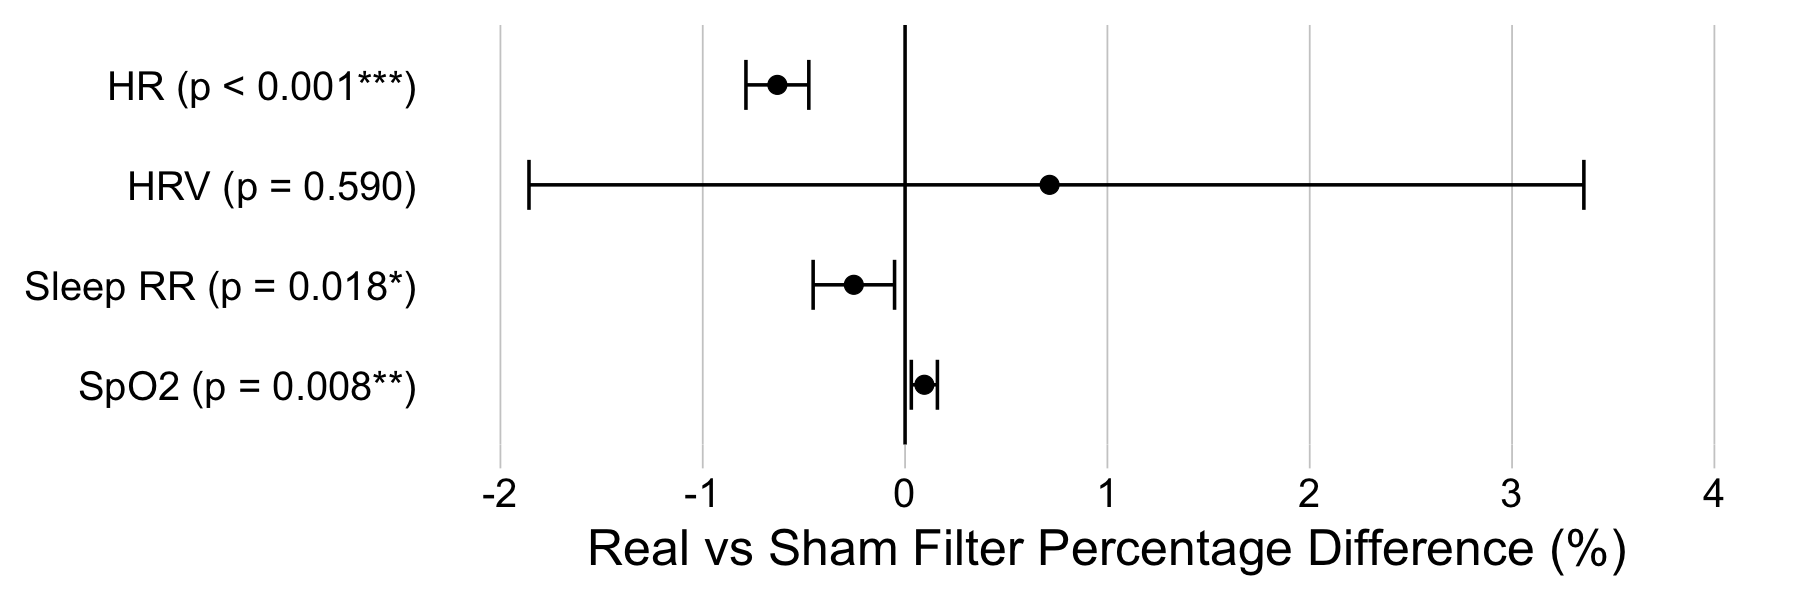

In [8]:
plot_fixed_effect_percentage(
    main_fixed_effect =  "treatmenttreatment2",
    summaries = health_metric_treatment_lme_summaries, 
    health_metric_names = HEALTH_METRIC_NAMES, 
    is_black_bg = FALSE,
    title = "Real vs Sham Filter Percentage Difference (%)",
    file_name = "percentage_change_health_metrics_treatment.pdf"
)

In [9]:
health_metric_treatment_report_df <- make_reporting_treatment_df(
  lme_summaries = health_metric_treatment_lme_summaries,
  trt1 = "treatment1",
  trt2 = "treatment2",
  trt2_term = "treatmenttreatment2",
  metric_labels = HEALTH_METRIC_LABELS_LATEX
)

health_metric_treatment_report_df

latex_tbl <- kable(
  health_metric_treatment_report_df, "latex", booktabs = TRUE, escape = FALSE,
  align = "llcccc",
  col.names = c(
  "Metric",  TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "Percentage Changes (Real vs. Sham)", "P-Value\\tnote{a}"),
  label = "health_metrics_vs_treatment"
                   ) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))

latex_tbl

metric,emmean1_pm_se,emmean2_pm_se,pct_change_iqr,p_value
<chr>,<chr>,<chr>,<chr>,<chr>
HR (beats/min),$66.71~\pm~1.19$,$66.29~\pm~1.18$,"$-0.63\%$ $[-0.79, -0.48]$",\textbf{<0.001$^{***}$}
HRV (ms),$54.66~\pm~2.78$,$55.05~\pm~2.81$,"$+0.71\%$ $[-1.86, +3.35]$",0.590
Sleep RR (breaths/min),$14.76~\pm~0.32$,$14.72~\pm~0.32$,"$-0.25\%$ $[-0.45, -0.05]$",\textbf{0.018$^*$}
SpO$_2$ (\%),$97.16~\pm~0.11$,$97.26~\pm~0.11$,"$+0.10\%$ $[+0.03, +0.16]$",\textbf{0.008$^{**}$}


\begin{table}[!h]
\centering
\begin{tabular}{llccc}
\toprule
Metric & Sham Filter & Real Filter & Percentage Changes (Real vs. Sham) & P-Value\tnote{a}\\
\midrule
HR (beats/min) & $66.71~\pm~1.19$ & $66.29~\pm~1.18$ & $-0.63\%$ $[-0.79, -0.48]$ & \textbf{<0.001$^{***}$}\\
HRV (ms) & $54.66~\pm~2.78$ & $55.05~\pm~2.81$ & $+0.71\%$ $[-1.86, +3.35]$ & 0.590\\
Sleep RR (breaths/min) & $14.76~\pm~0.32$ & $14.72~\pm~0.32$ & $-0.25\%$ $[-0.45, -0.05]$ & \textbf{0.018$^*$}\\
SpO$_2$ (\%) & $97.16~\pm~0.11$ & $97.26~\pm~0.11$ & $+0.10\%$ $[+0.03, +0.16]$ & \textbf{0.008$^{**}$}\\
\bottomrule
\end{tabular}
\end{table}

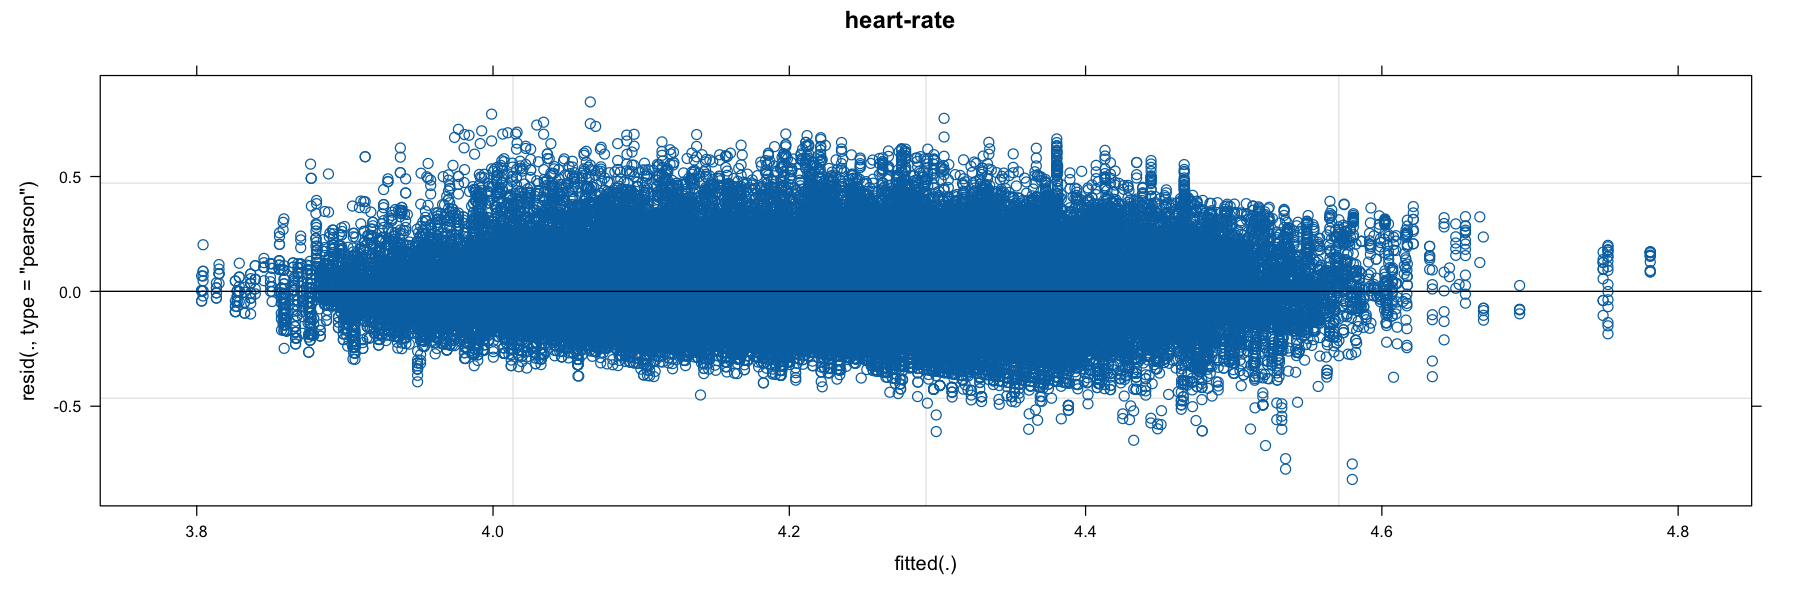

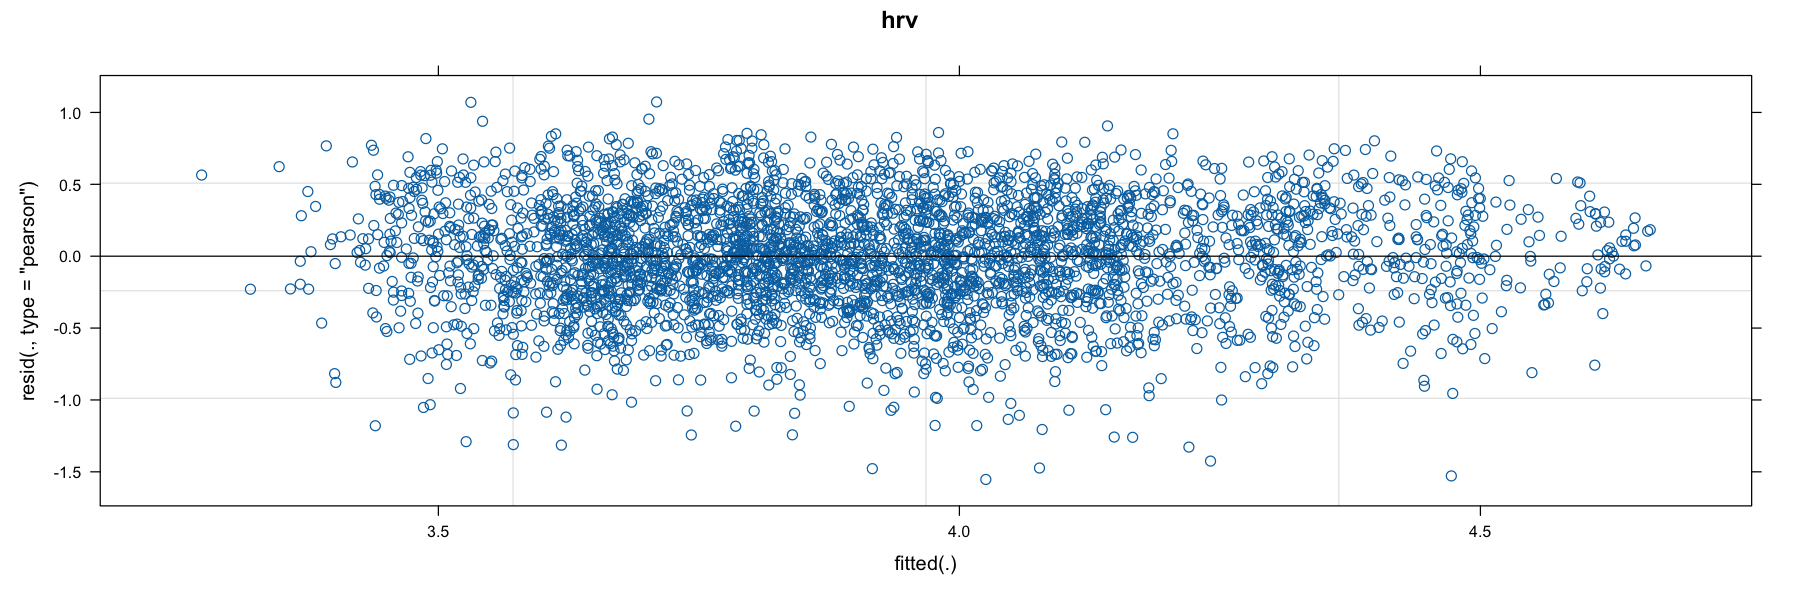

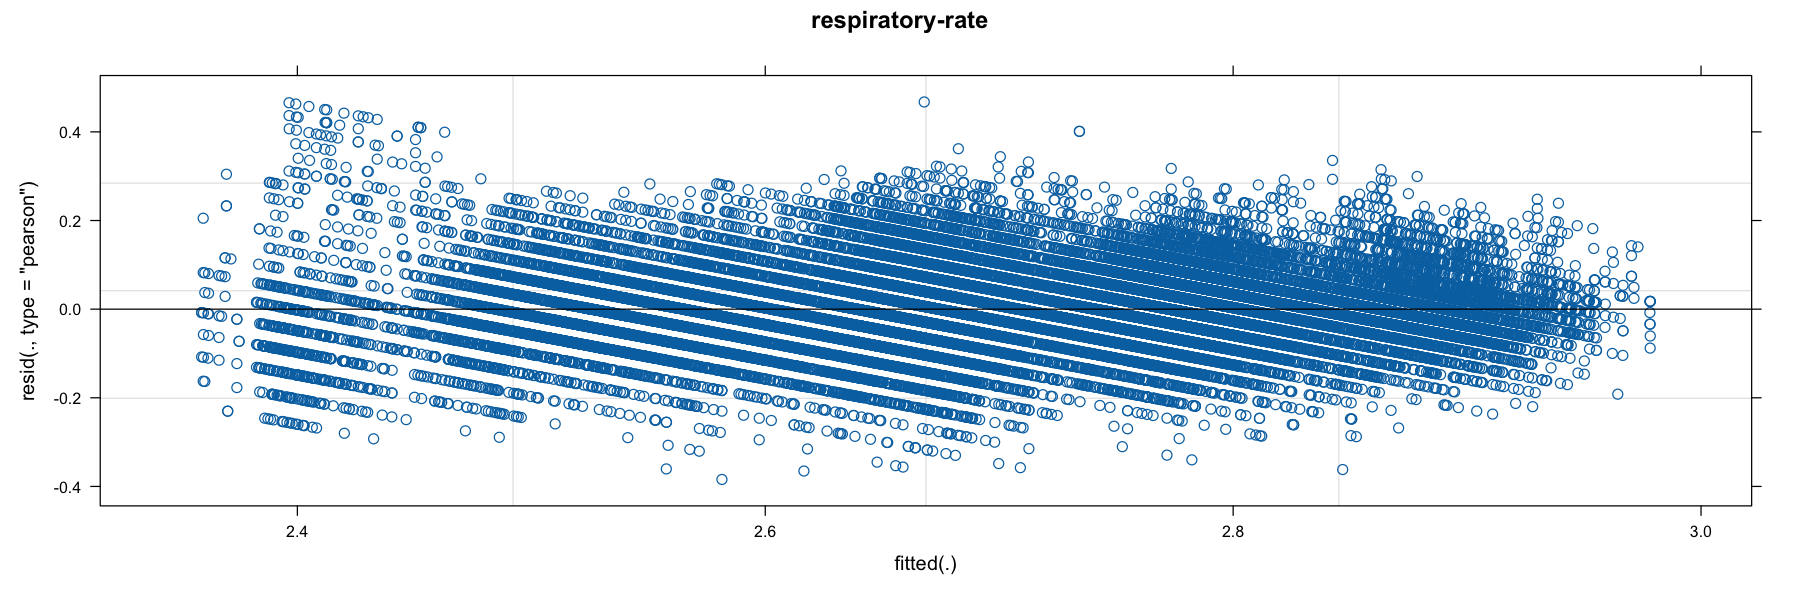

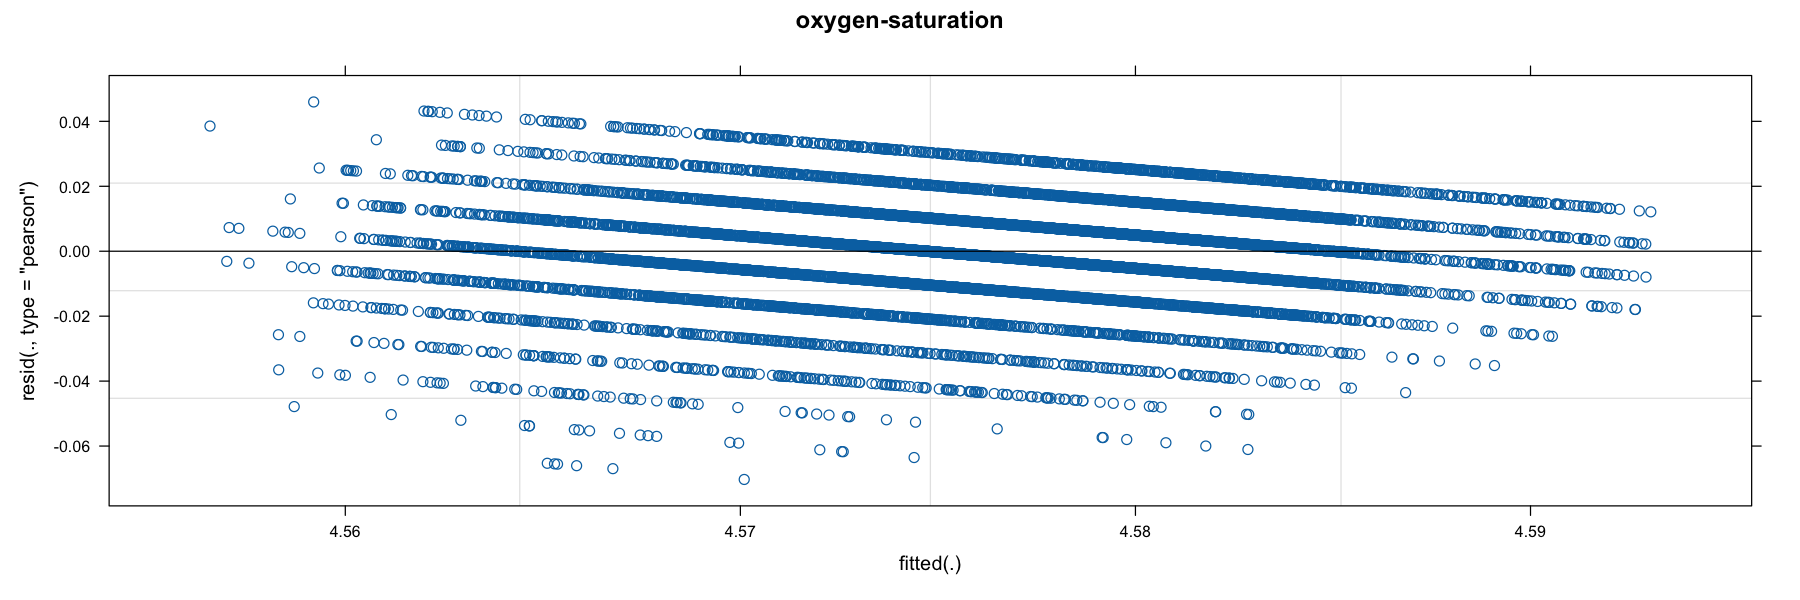

In [10]:
plot_lme_residuals_vs_fitted(health_metric_treatment_lme_summaries)

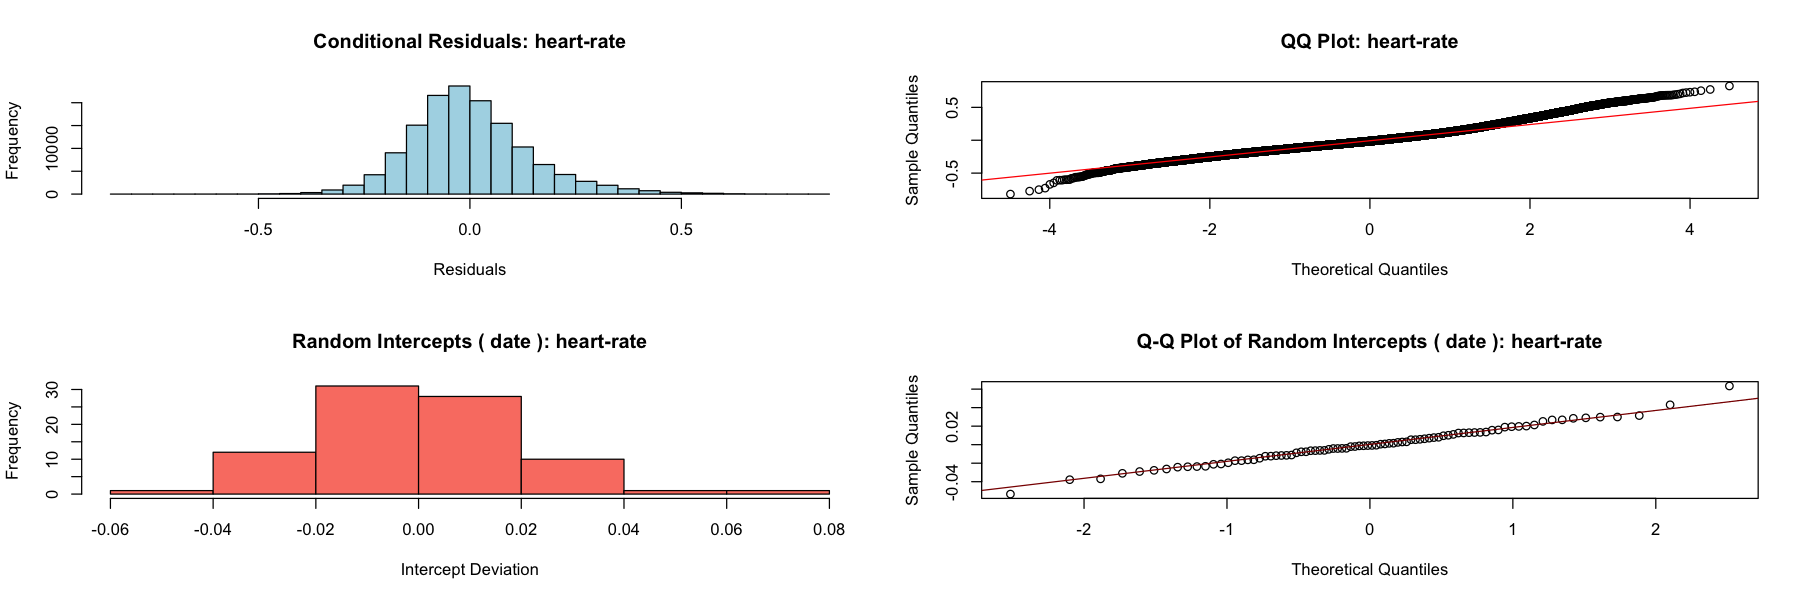

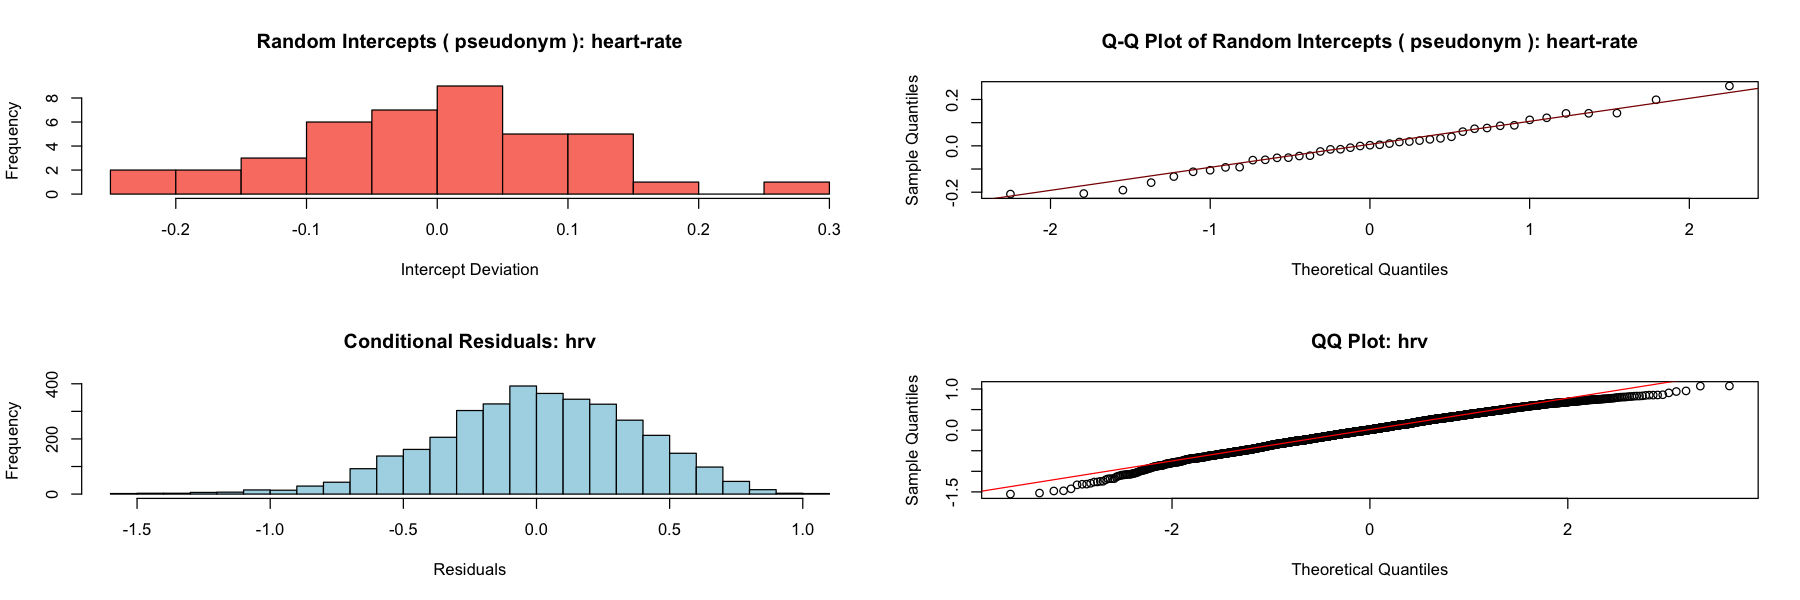

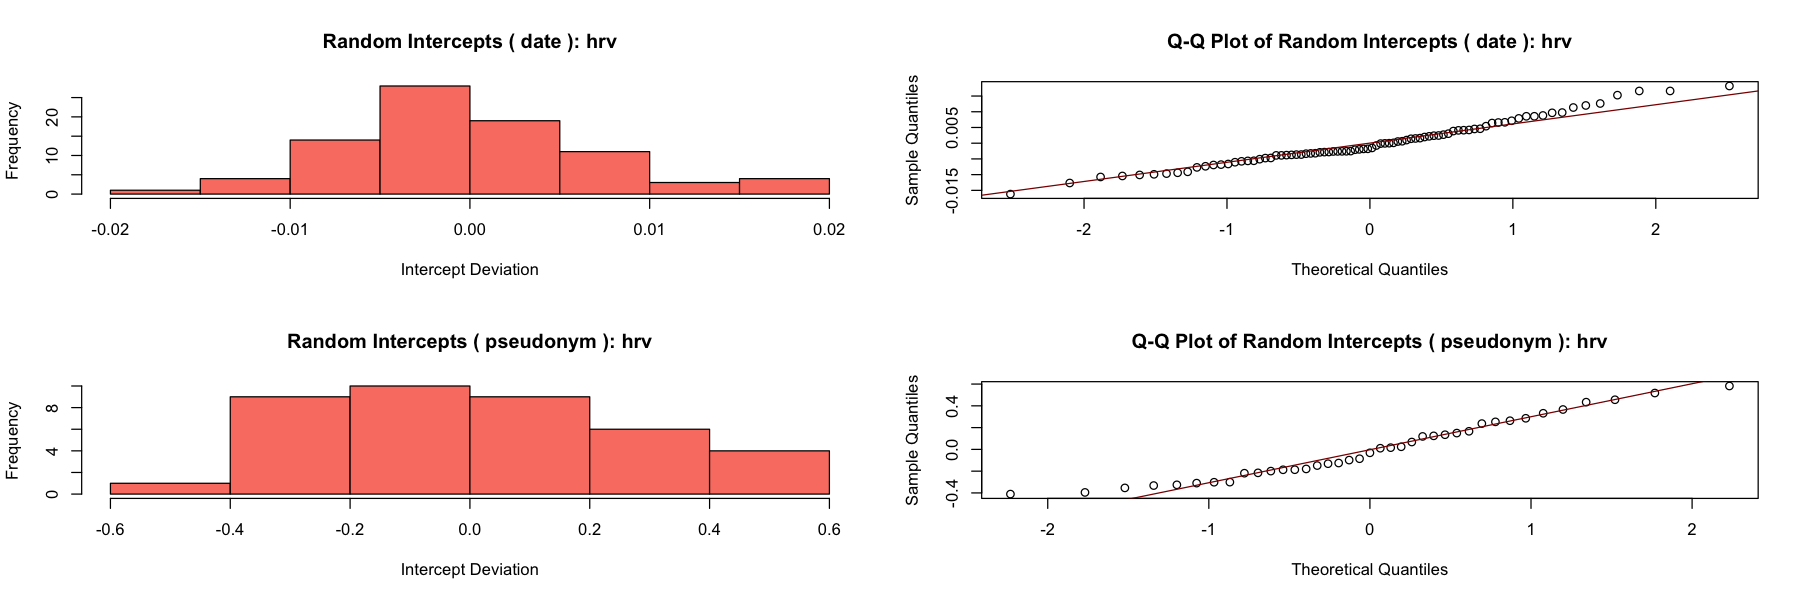

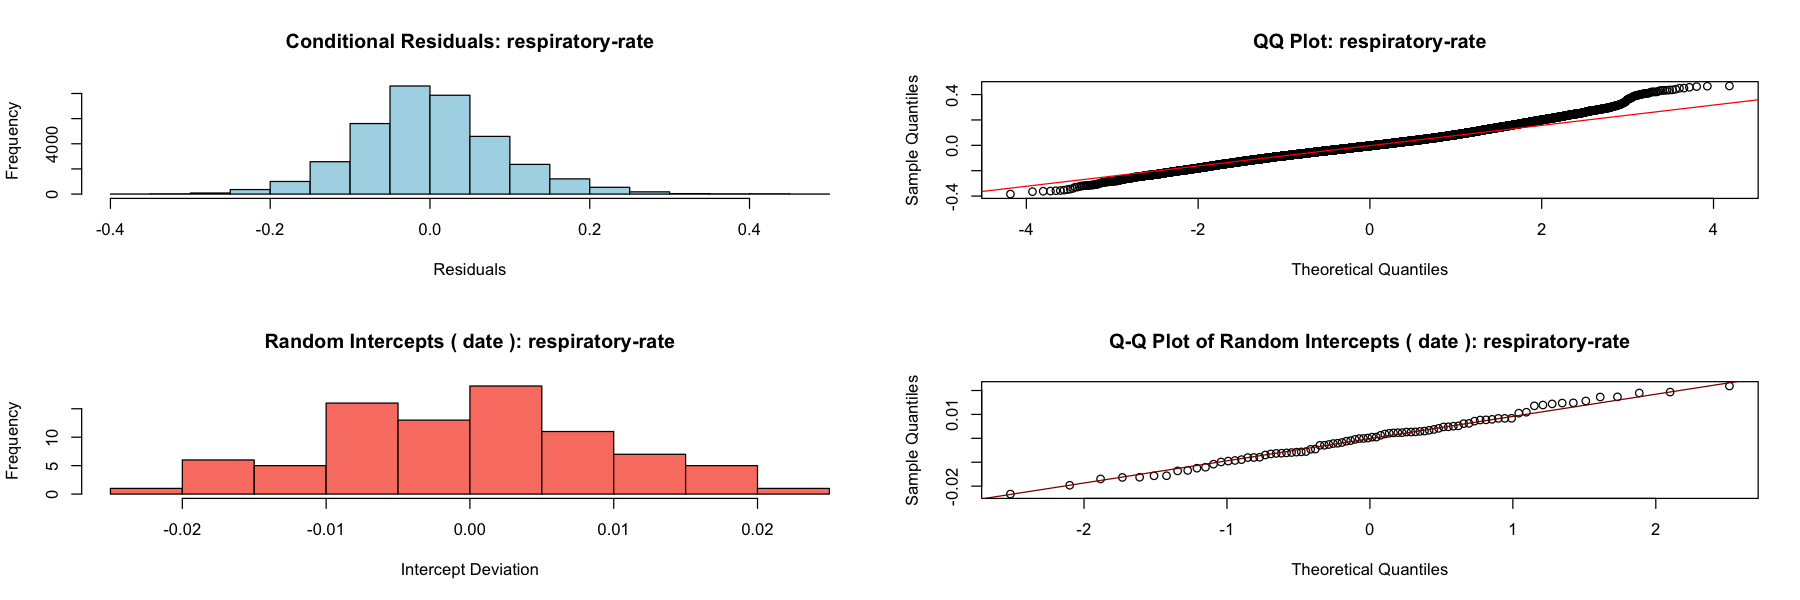

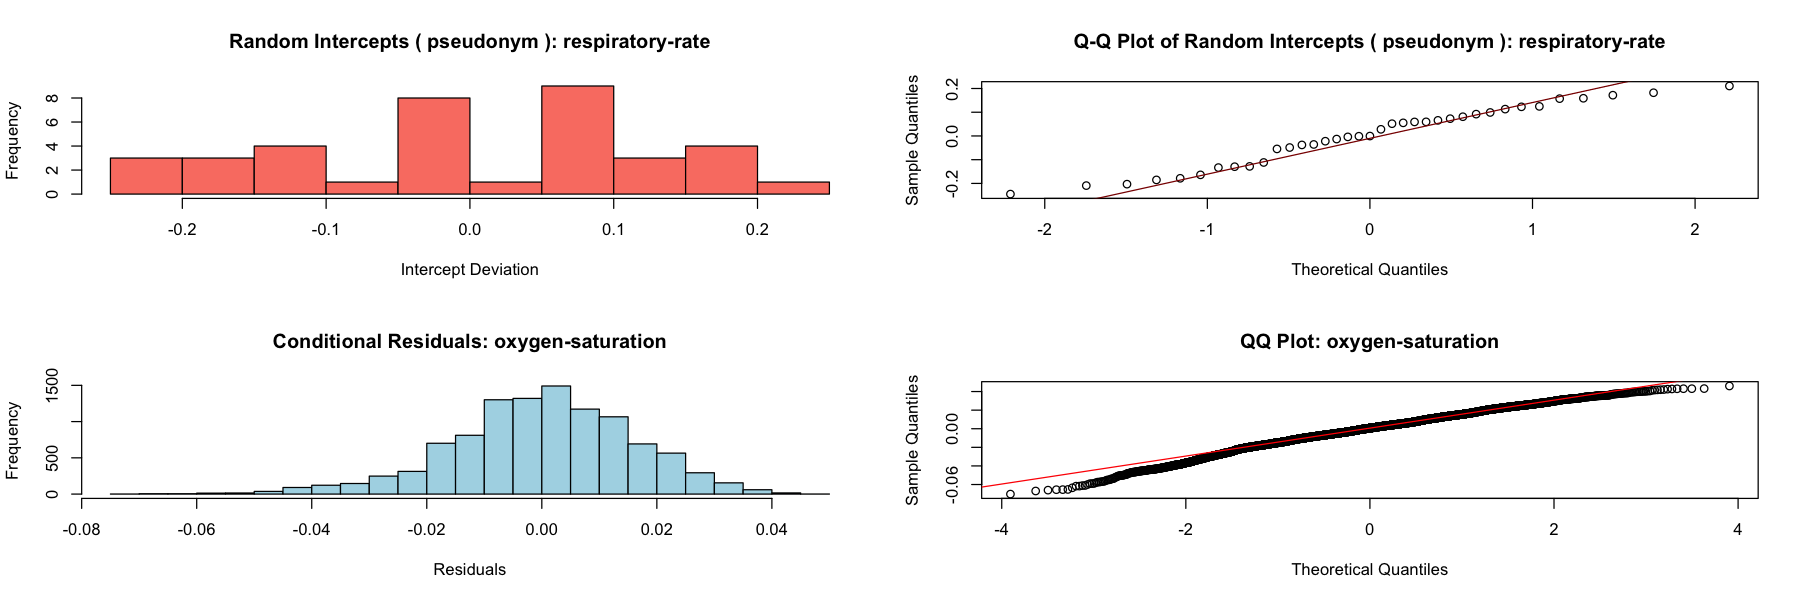

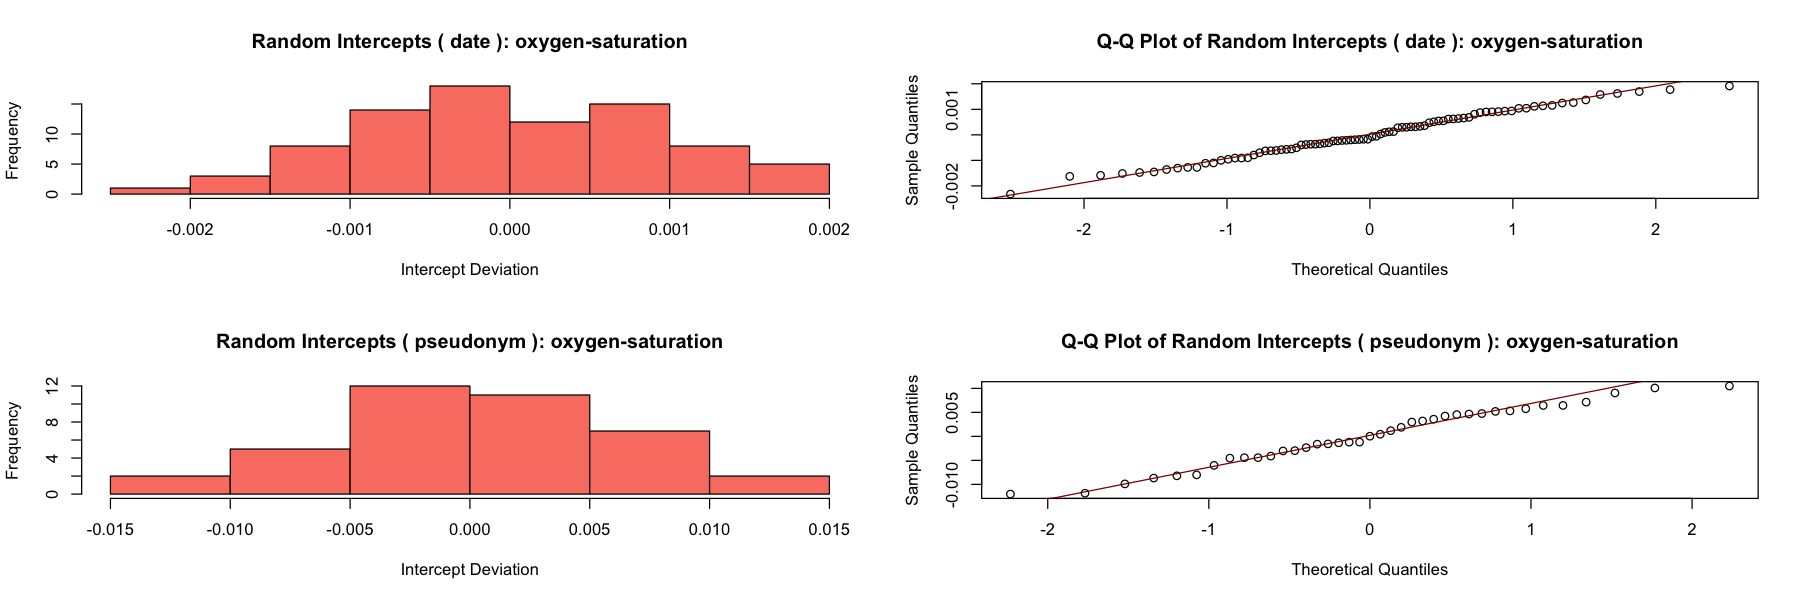

In [11]:
plot_lme_diagnostics(health_metric_treatment_lme_summaries)

### 5.2.2. PM2.5 exposure <-> Health metric

In [12]:
health_metric_pm25_lme_models <- fit_lme_models(
    main_fixed_effect = "pm25",
    metric_dfs = HEALTH_METRIC_WITH_EXPOSURE_DFS
)
health_metric_pm25_lme_summaries <- imap(health_metric_pm25_lme_models, 
    ~extract_model_info(
        model = .x$model,
        main_fixed_effect_iqr = .x$main_fixed_effect_iqr,
        df_used = .x$df_used,
        metric_name = .y,
        main_fixed_effect = "pm25"
        )
    )
    
health_metric_pm25_lme_summaries <- adjust_pvalues_bh(lme_summaries = health_metric_pm25_lme_summaries, main_fixed_effect = "pm25")

[1] "Fitting model for metric: heart-rate"
[1] "Fitting model for metric: resting-heart-rate"


boundary (singular) fit: see help('isSingular')



[1] "Fitting model for metric: hrv"
[1] "Fitting model for metric: respiratory-rate"
[1] "Fitting model for metric: oxygen-saturation"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 223822' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 223822)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 223822' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 223822)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for heart-rate = 73.93"
[1] "Adjusted overall mean for resting-heart-rate = 63.66"


...

[1] "Adjusted overall mean for hrv = 51.83"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 36401' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 36401)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 36401' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 36401)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for respiratory-rate = 14.83"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 13029' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 13029)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 13029' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 13029)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for oxygen-saturation = 97.24"


In [13]:
view_lme_summary_details(lme_summaries = health_metric_pm25_lme_summaries)

log(value) ~ pm25 + bmi + biological_sex + ns(temperature, df = 3) + 
    ns(humidity, df = 3) + ns(co2, df = 3) + dow + heart_rate_motion_context + 
    ns(hour, df = 3) + location_type + (1 | pseudonym + date)
<environment: 0x118e28838>

metric,REMLcrit,residual_stddev,nobs
<chr>,<dbl>,<dbl>,<int>
heart-rate,-215176,0.1493549,223822


effect,term,estimate,2.5 %,97.5 %,std.error,statistic,df,p.value,percent_change,percent_change_low,percent_change_high,percent_change_iqr,percent_change_iqr_low,percent_change_iqr_high,adjusted_p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),4.417728672,4.360534887,4.474922457,0.0291810389,151.3903837,53.37405,5.576991e-72,NA,NA,NA,NA,NA,NA,NA
fixed,pm25,0.008923754,0.007703448,0.010144060,0.0006226167,14.3326615,127402.62864,1.486912e-46,0.8963690,0.7733196,1.0195686,0.896369,0.7733196,1.019569,7.434558e-46
fixed,bmi,0.008311364,-0.024925497,0.041548225,0.0169578939,0.4901177,37.98819,6.268695e-01,0.8345999,-2.4617422,4.2423432,NA,NA,NA,NA
fixed,biological_sexMale,-0.011325450,-0.078837380,0.056186480,0.0344454951,-0.3287934,37.97151,7.441184e-01,-1.1261559,-7.5809796,5.7794922,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)1",0.046440650,0.037181298,0.055700002,0.0047242459,9.8302779,199218.63466,8.439129e-23,4.7535906,3.7881170,5.7280454,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)2",-0.003993833,-0.020519891,0.012532226,0.0084318176,-0.4736621,218290.47595,6.357413e-01,-0.3985868,-2.0310791,1.2611084,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)3",-0.238939279,-0.256529546,-0.221349012,0.0089747910,-26.6233808,219220.95676,6.458571e-156,-21.2537304,-22.6267867,-19.8563079,NA,NA,NA,NA
fixed,"ns(humidity, df = 3)1",-0.126294528,-0.137489737,-0.115099319,0.0057119463,-22.1105943,206958.61750,3.338592e-108,-11.8644775,-12.8456705,-10.8722381,NA,NA,NA,NA
fixed,"ns(humidity, df = 3)2",-0.344800806,-0.383033247,-0.306568365,0.0195067059,-17.6760140,222544.82278,7.165707e-70,-29.1638559,-31.8209769,-26.4031798,NA,NA,NA,NA


effect,group,term,variance,std.dev,2.5 %,97.5 %
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ran_pars,date,sd__(Intercept),0.0002893777,0.0170111,NA,NA
ran_pars,pseudonym,sd__(Intercept),0.0103366181,0.1016692,NA,NA
ran_pars,Residual,sd__Observation,0.0223068718,0.1493549,NA,NA


NULL

...

metric,REMLcrit,residual_stddev,nobs
<chr>,<dbl>,<dbl>,<int>
oxygen-saturation,-69529.91,0.01647168,13029


effect,term,estimate,2.5 %,97.5 %,std.error,statistic,df,p.value,percent_change,percent_change_low,percent_change_high,percent_change_iqr,percent_change_iqr_low,percent_change_iqr_high,adjusted_p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),4.5798545739,4.5527950547,4.606914e+00,0.0138061308,331.72614572,10173.85893,0.000000e+00,NA,NA,NA,NA,NA,NA,NA
fixed,pm25,-0.0003481603,-0.0007713767,7.505609e-05,0.0002159307,-1.61237056,1666.44366,1.070707e-01,-0.03480997,-0.07710793,0.0075058911,-0.03480997,-0.07710793,0.007505891,0.1070707
fixed,bmi,-0.0002871148,-0.0024767612,1.902532e-03,0.0011171870,-0.25699798,35.55992,7.986616e-01,-0.02870736,-0.24736965,0.1904342514,NA,NA,NA,NA
fixed,biological_sexMale,0.0013230798,-0.0031844976,5.830657e-03,0.0022998266,0.57529544,35.37958,5.687326e-01,0.13239554,-0.31794325,0.5847688523,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)1",-0.0021896105,-0.0067239268,2.344706e-03,0.0023134692,-0.94646193,4380.58591,3.439652e-01,-0.21872151,-0.67013718,0.2347456733,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)2",0.0002855637,-0.0083286979,8.899825e-03,0.0043951122,0.06497302,10170.78822,9.481968e-01,0.02856045,-0.82941104,0.8939546528,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)3",0.0006253545,-0.0102392385,1.148995e-02,0.0055432615,0.11281346,11680.55014,9.101804e-01,0.06255501,-1.01869959,1.1556210499,NA,NA,NA,NA
fixed,"ns(humidity, df = 3)1",-0.0016519039,-0.0077100408,4.406233e-03,0.0030909429,-0.53443366,6991.76351,5.930585e-01,-0.16505403,-0.76803946,0.4415954605,NA,NA,NA,NA
fixed,"ns(humidity, df = 3)2",0.0036923784,-0.0182742617,2.565902e-02,0.0112076754,0.32945087,11832.86460,7.418208e-01,0.36992036,-1.81082999,2.5991044837,NA,NA,NA,NA


effect,group,term,variance,std.dev,2.5 %,97.5 %
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ran_pars,date,sd__(Intercept),1.383450e-06,0.001176202,NA,NA
ran_pars,pseudonym,sd__(Intercept),4.213808e-05,0.006491385,NA,NA
ran_pars,Residual,sd__Observation,2.713163e-04,0.016471682,NA,NA


NULL

[1] "main_fixed_effect_iqr: 9"
[1] "main_fixed_effect_iqr: 7.41667994461069"
[1] "main_fixed_effect_iqr: 8.76959594517418"
[1] "main_fixed_effect_iqr: 5.5"
[1] "main_fixed_effect_iqr: 7.13888888888889"


[1] "Saved image"


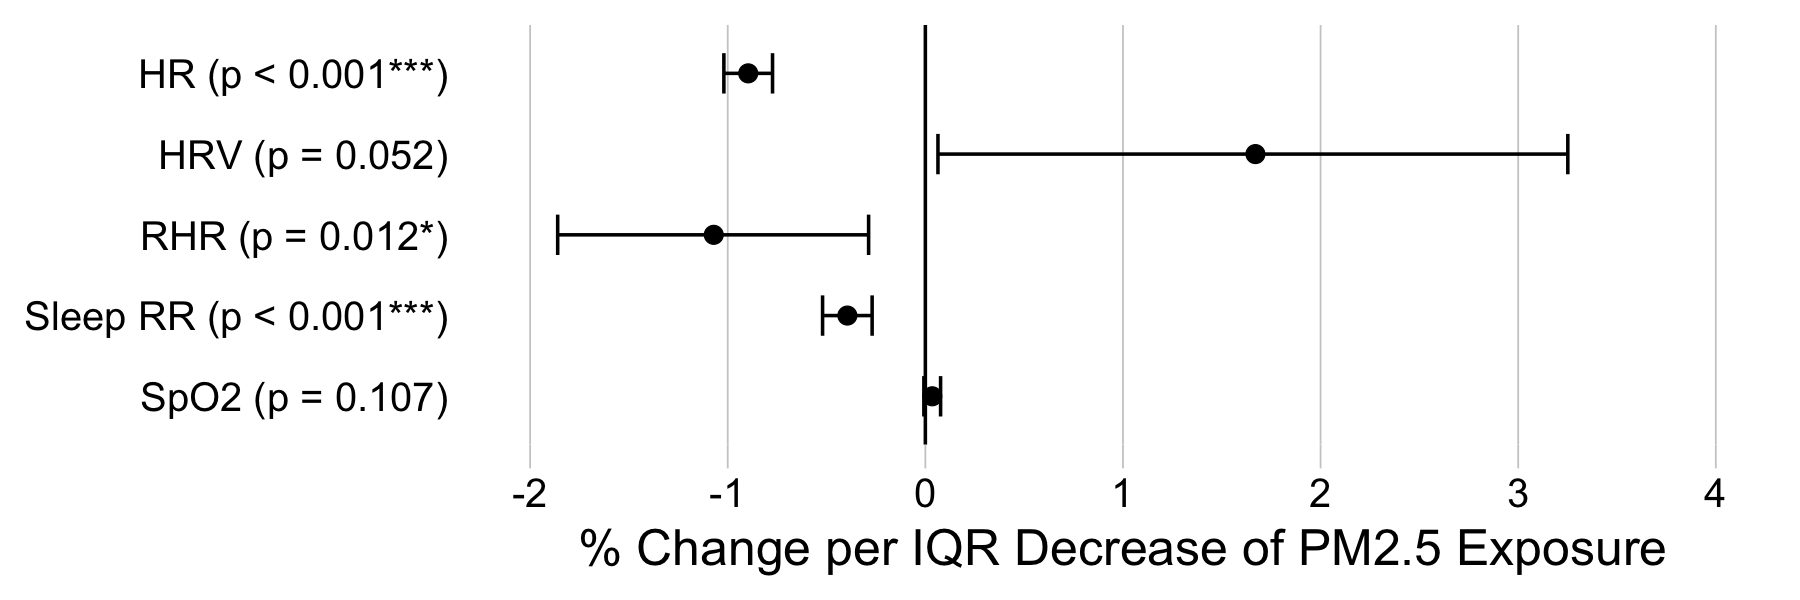

In [14]:
plot_fixed_effect_percentage(
    main_fixed_effect = "pm25",
    summaries = health_metric_pm25_lme_summaries, 
    health_metric_names = HEALTH_METRIC_NAMES, 
    is_black_bg = FALSE,
    title = "% Change per IQR Decrease of PM2.5 Exposure",
    flip_direction = TRUE,
    file_name = "percentage_change_health_metrics_pm25.pdf"
)

In [15]:
health_metric_pm25_report_df <- make_reporting_pm25_df(
  lme_summaries = health_metric_pm25_lme_summaries,
  pm25_term = "pm25",
  flip_direction = TRUE,
  metric_labels = HEALTH_METRIC_LABELS_LATEX
)

health_metric_pm25_report_df

latex_tbl <- kable(
  health_metric_pm25_report_df, "latex", booktabs = TRUE, escape = FALSE,
  align = "llcccc",
  col.names = c(
  "Metric", "PM2.5 IQR", "Mean Percentage Change [95\\% CI]", "P-Value\\tnote{a}"),
  label = "health_metrics_vs_pm25"
                   ) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))

latex_tbl

metric,main_fixed_effect_iqr,pct_change_iqr,p_value
<chr>,<dbl>,<chr>,<chr>
HR (beats/min),9.0,"$-0.90\%$ $[-1.02, -0.77]$",\textbf{<0.001$^{***}$}
HRV (ms),8.8,"$+1.67\%$ $[+0.06, +3.25]$",0.052
RHR (beats/min),7.4,"$-1.07\%$ $[-1.86, -0.29]$",\textbf{0.012$^*$}
Sleep RR (breaths/min),5.5,"$-0.39\%$ $[-0.52, -0.27]$",\textbf{<0.001$^{***}$}
SpO$_2$ (\%),7.1,"$+0.03\%$ $[-0.01, +0.08]$",0.107


\begin{table}[!h]
\centering
\begin{tabular}{llcc}
\toprule
Metric & PM2.5 IQR & Mean Percentage Change [95\% CI] & P-Value\tnote{a}\\
\midrule
HR (beats/min) & 9.0 & $-0.90\%$ $[-1.02, -0.77]$ & \textbf{<0.001$^{***}$}\\
HRV (ms) & 8.8 & $+1.67\%$ $[+0.06, +3.25]$ & 0.052\\
RHR (beats/min) & 7.4 & $-1.07\%$ $[-1.86, -0.29]$ & \textbf{0.012$^*$}\\
Sleep RR (breaths/min) & 5.5 & $-0.39\%$ $[-0.52, -0.27]$ & \textbf{<0.001$^{***}$}\\
SpO$_2$ (\%) & 7.1 & $+0.03\%$ $[-0.01, +0.08]$ & 0.107\\
\bottomrule
\end{tabular}
\end{table}

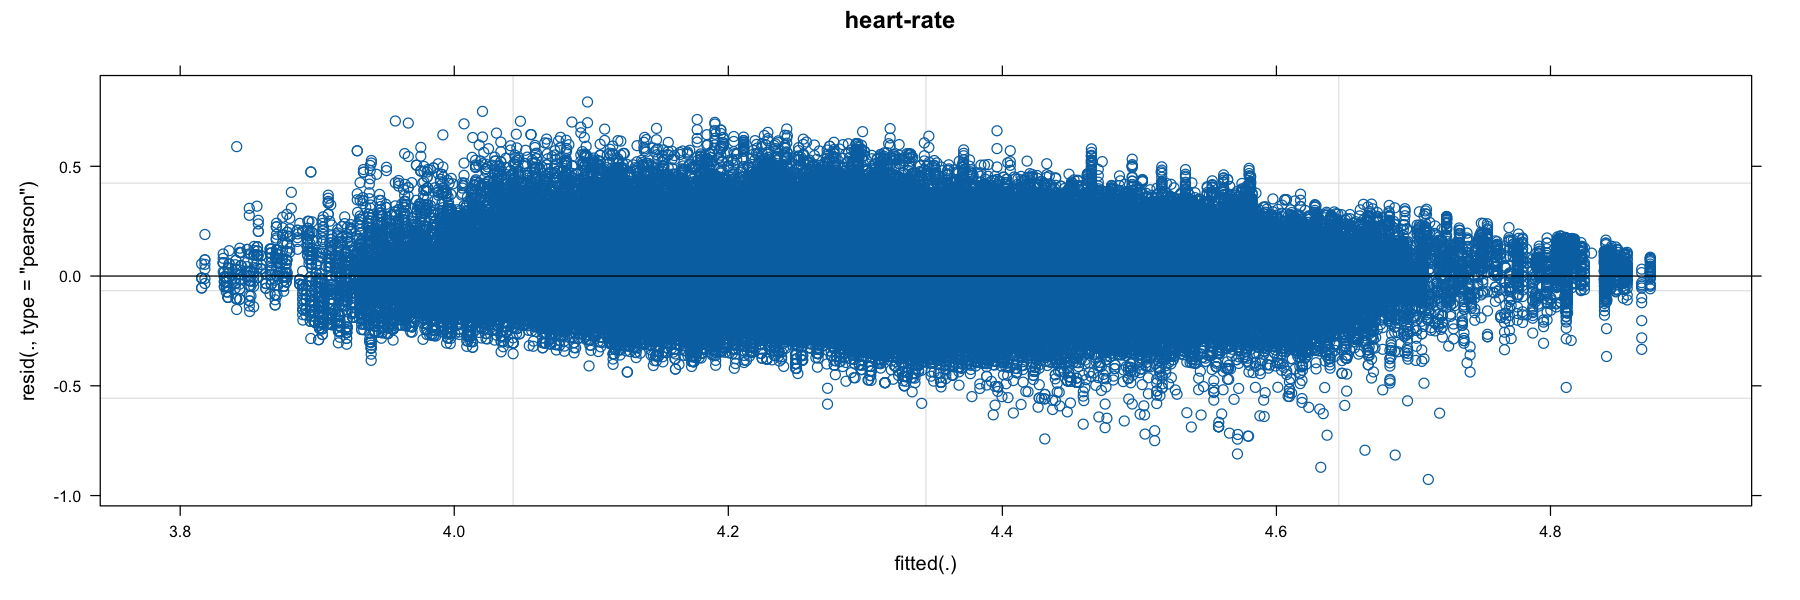

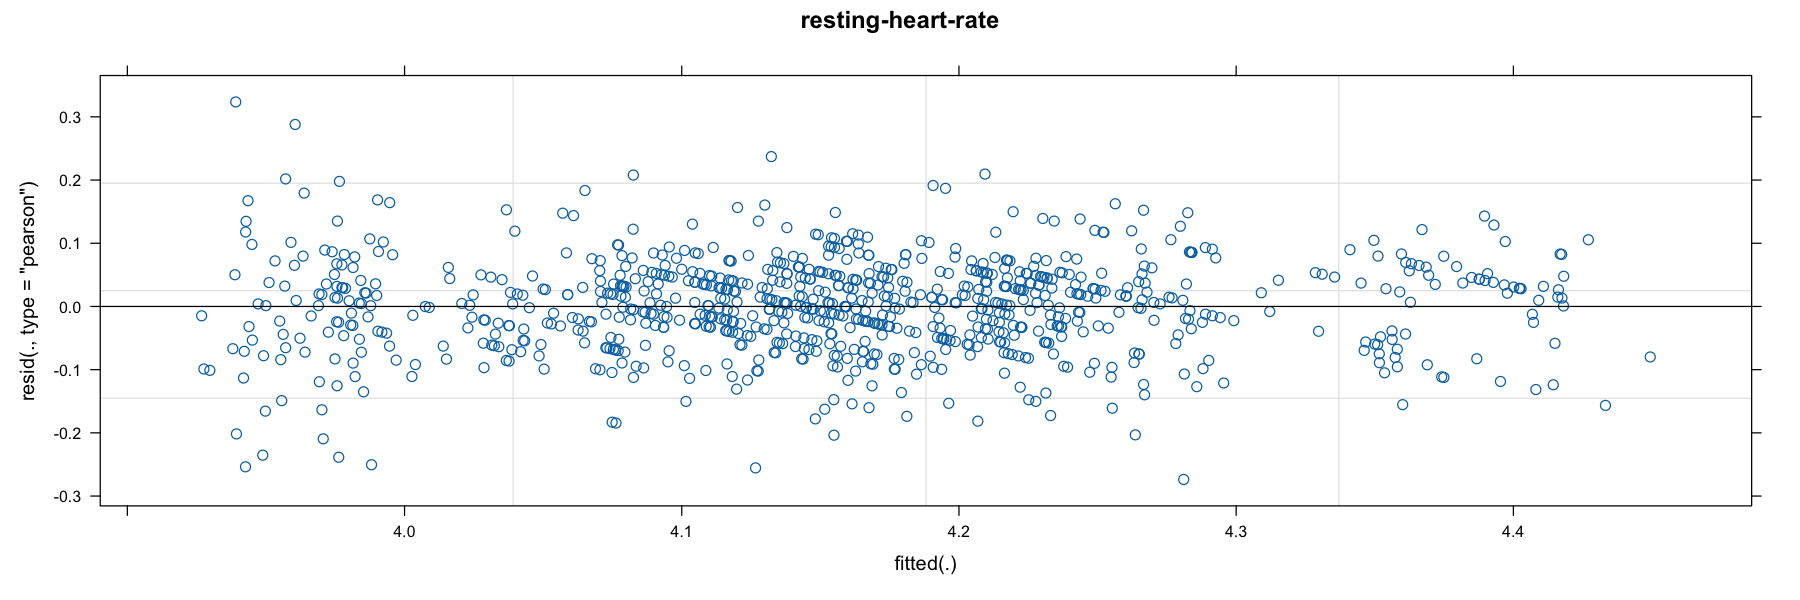

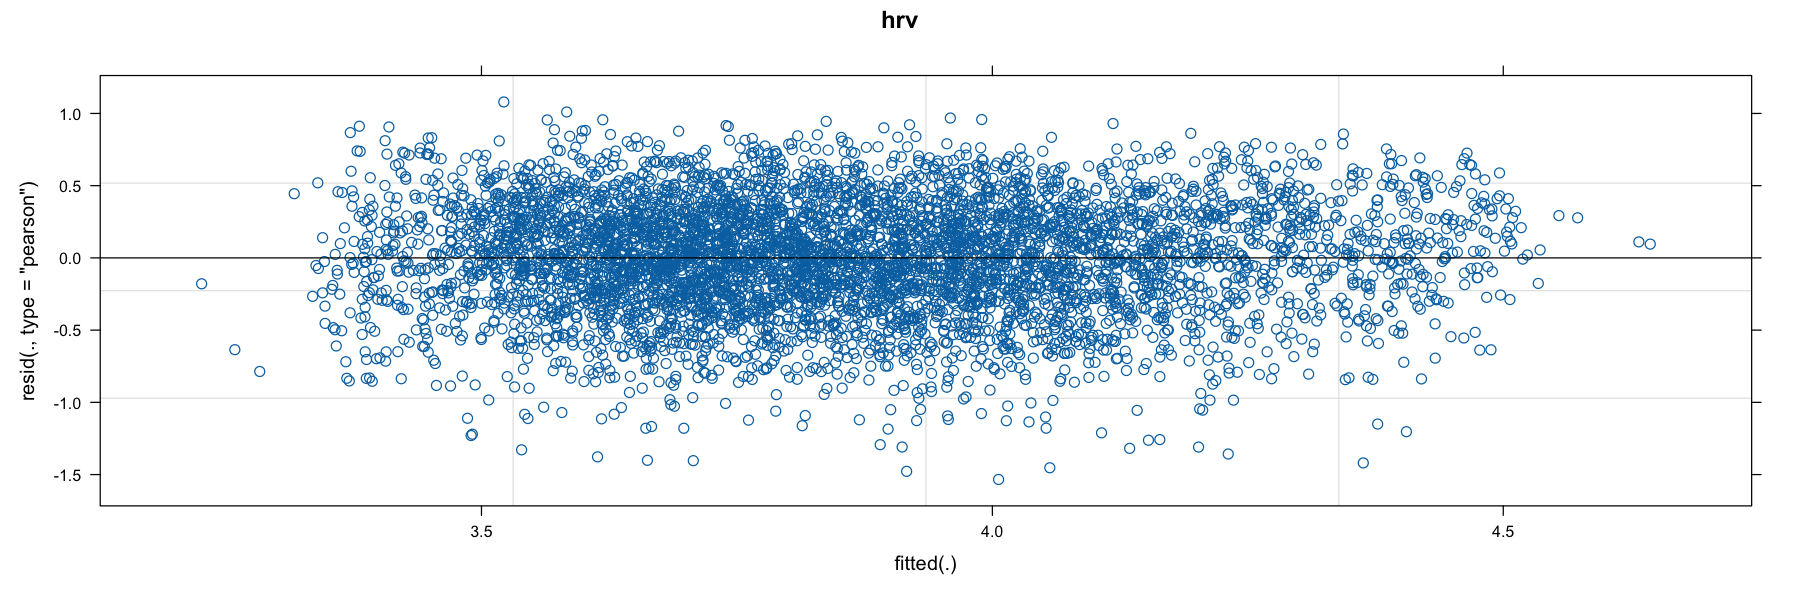

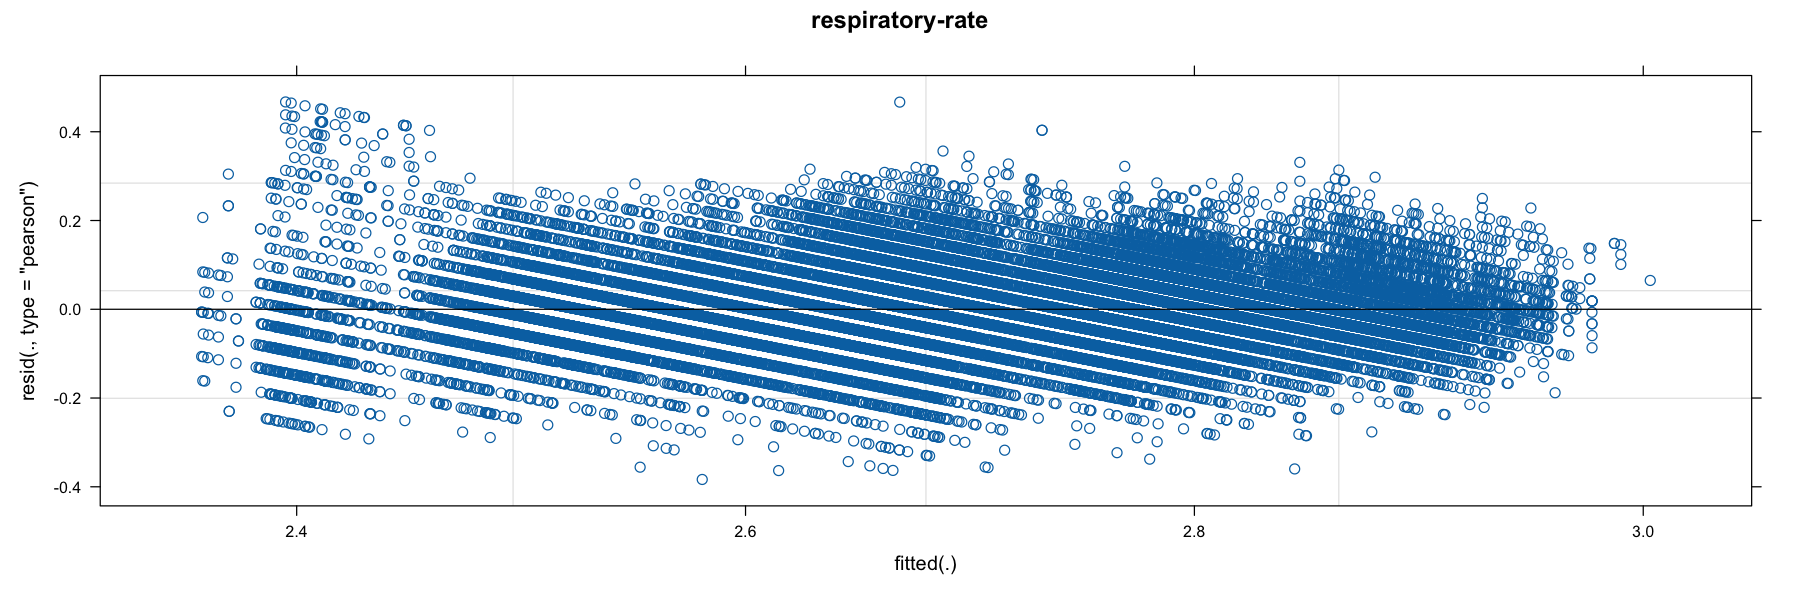

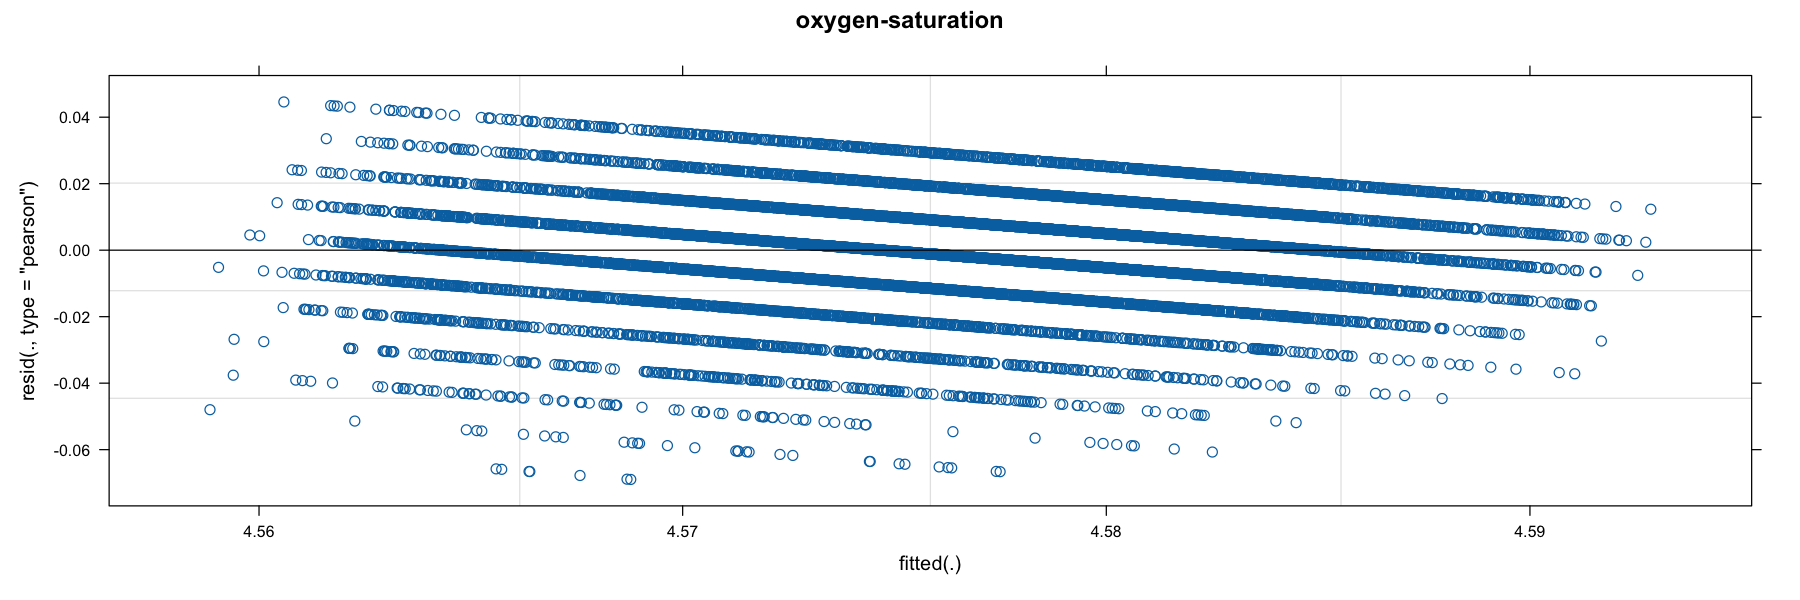

In [16]:
plot_lme_residuals_vs_fitted(health_metric_pm25_lme_summaries)

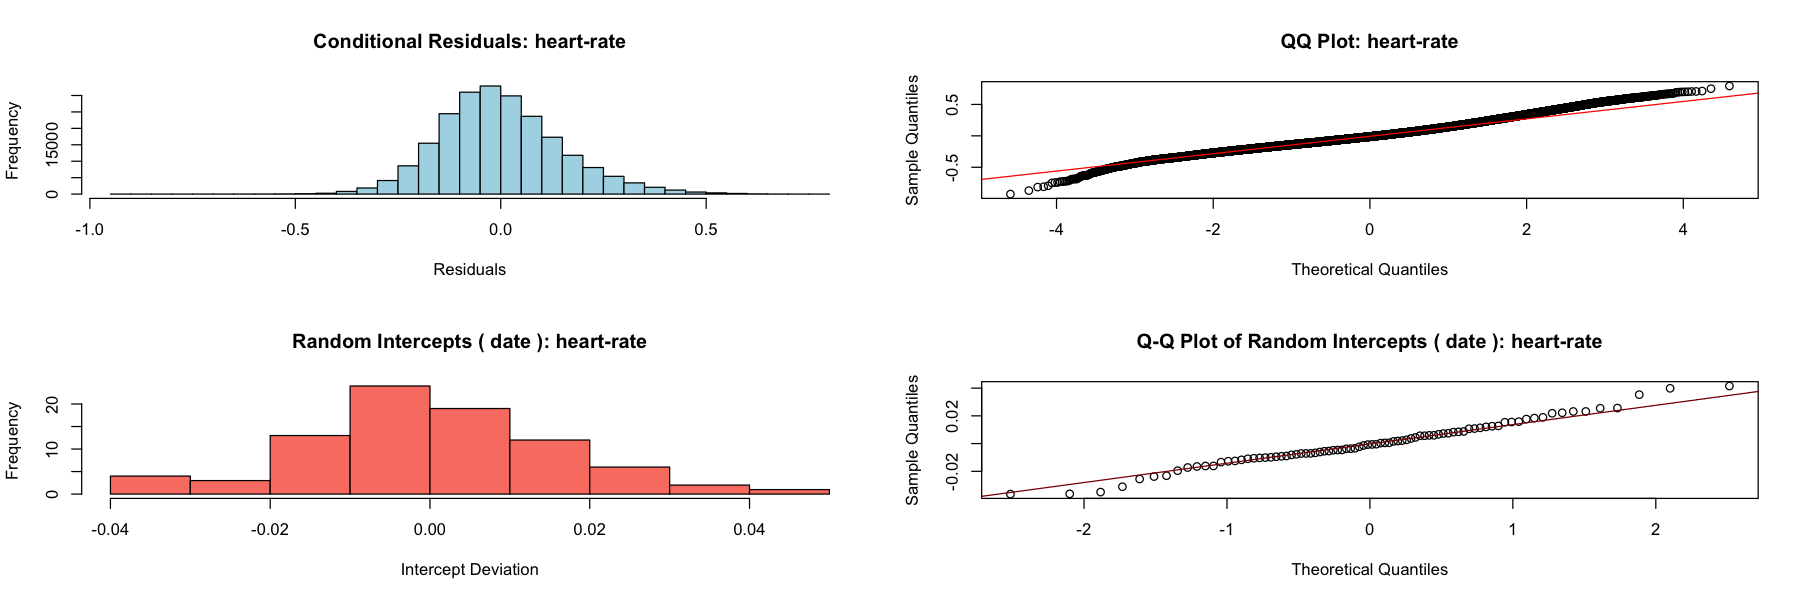

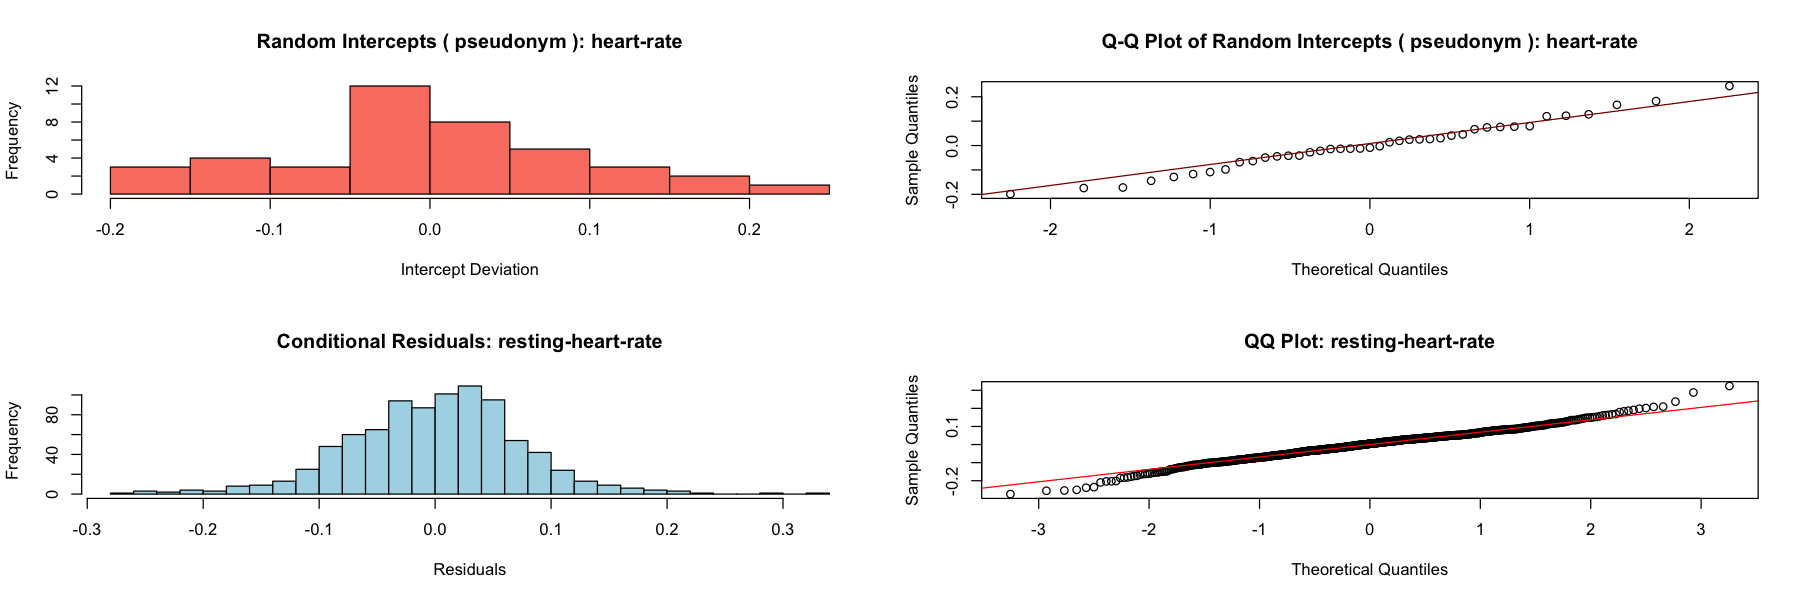

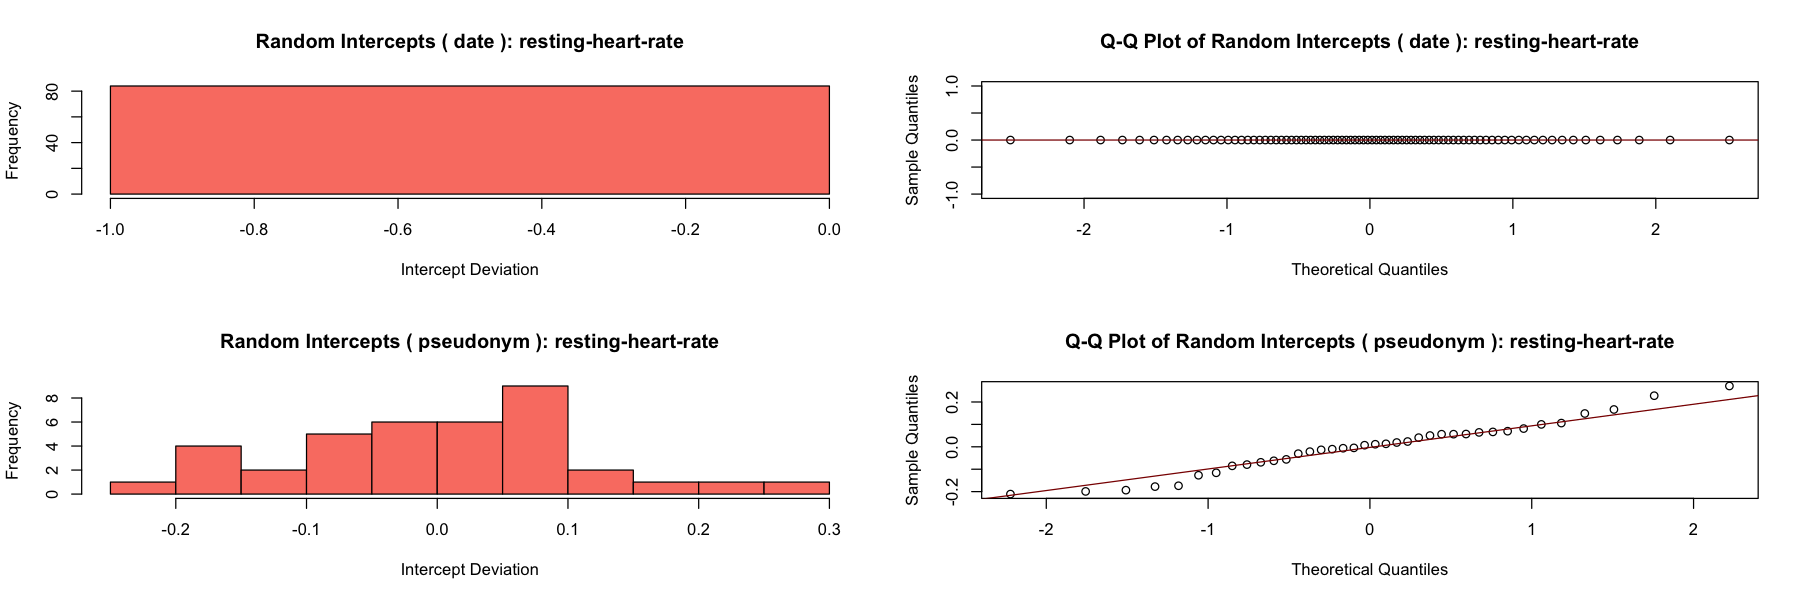

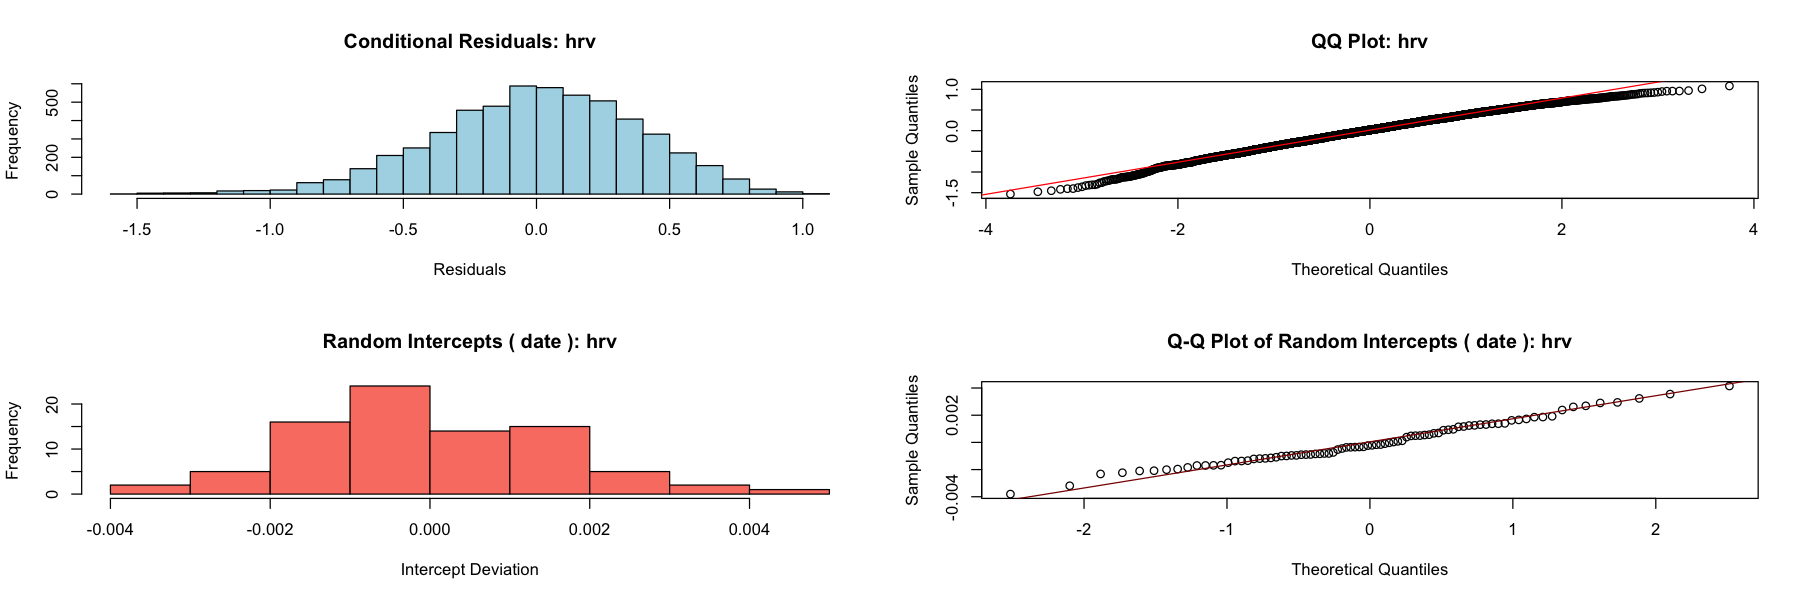

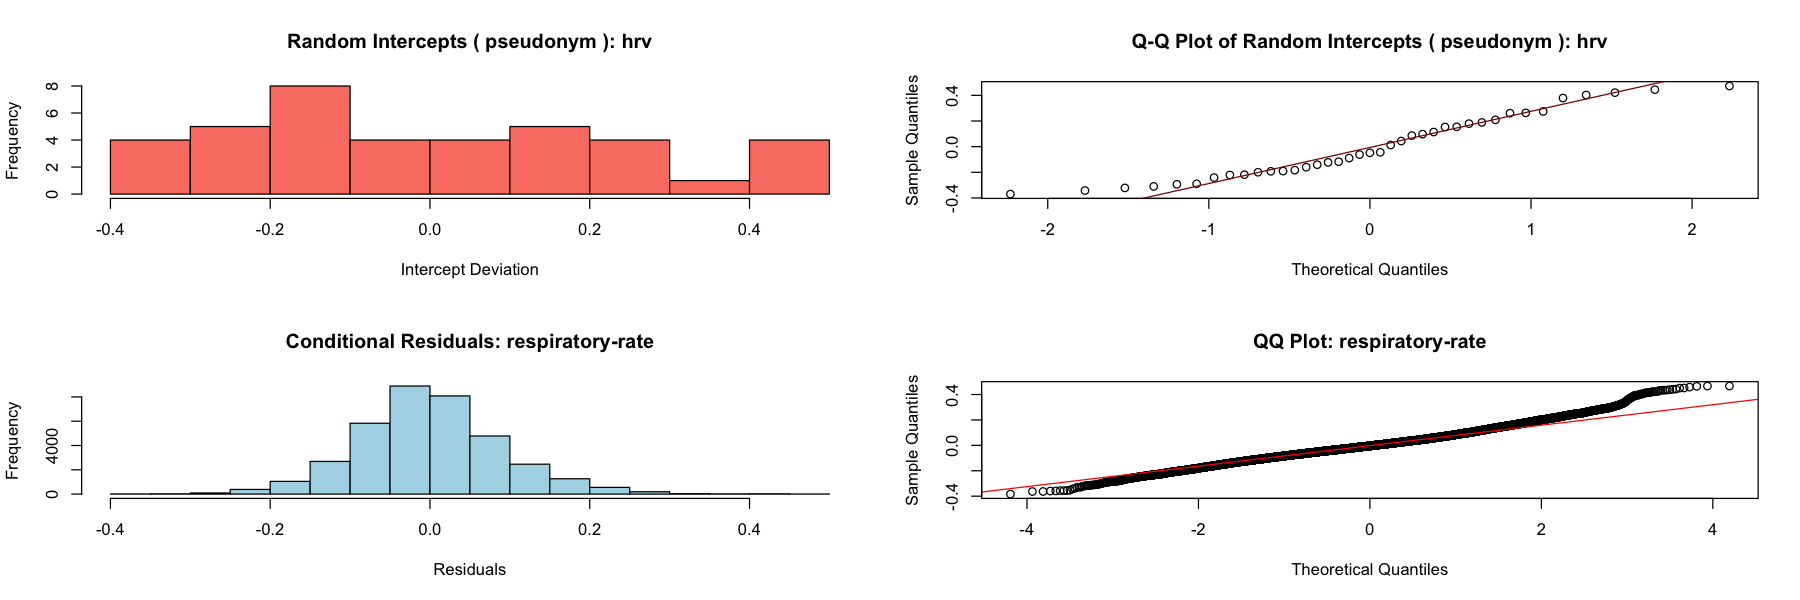

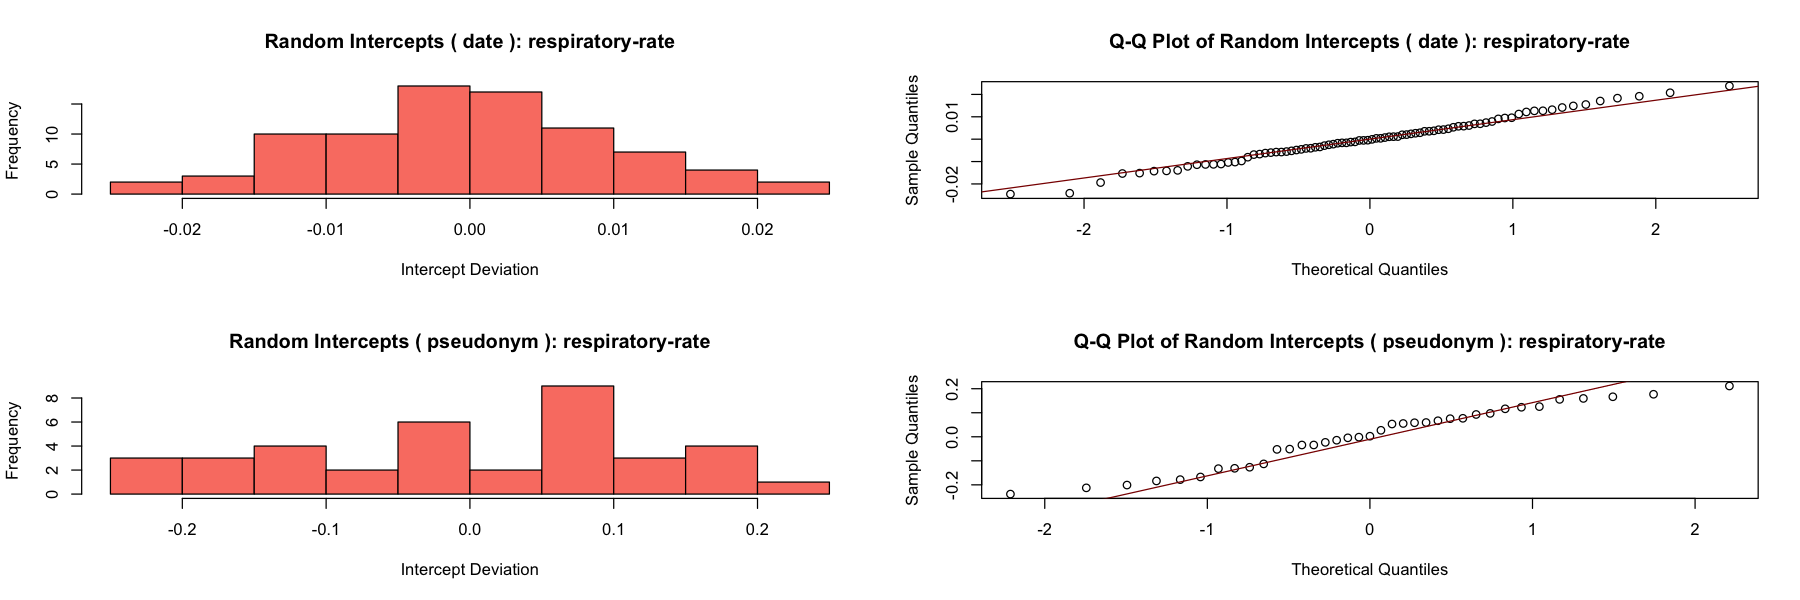

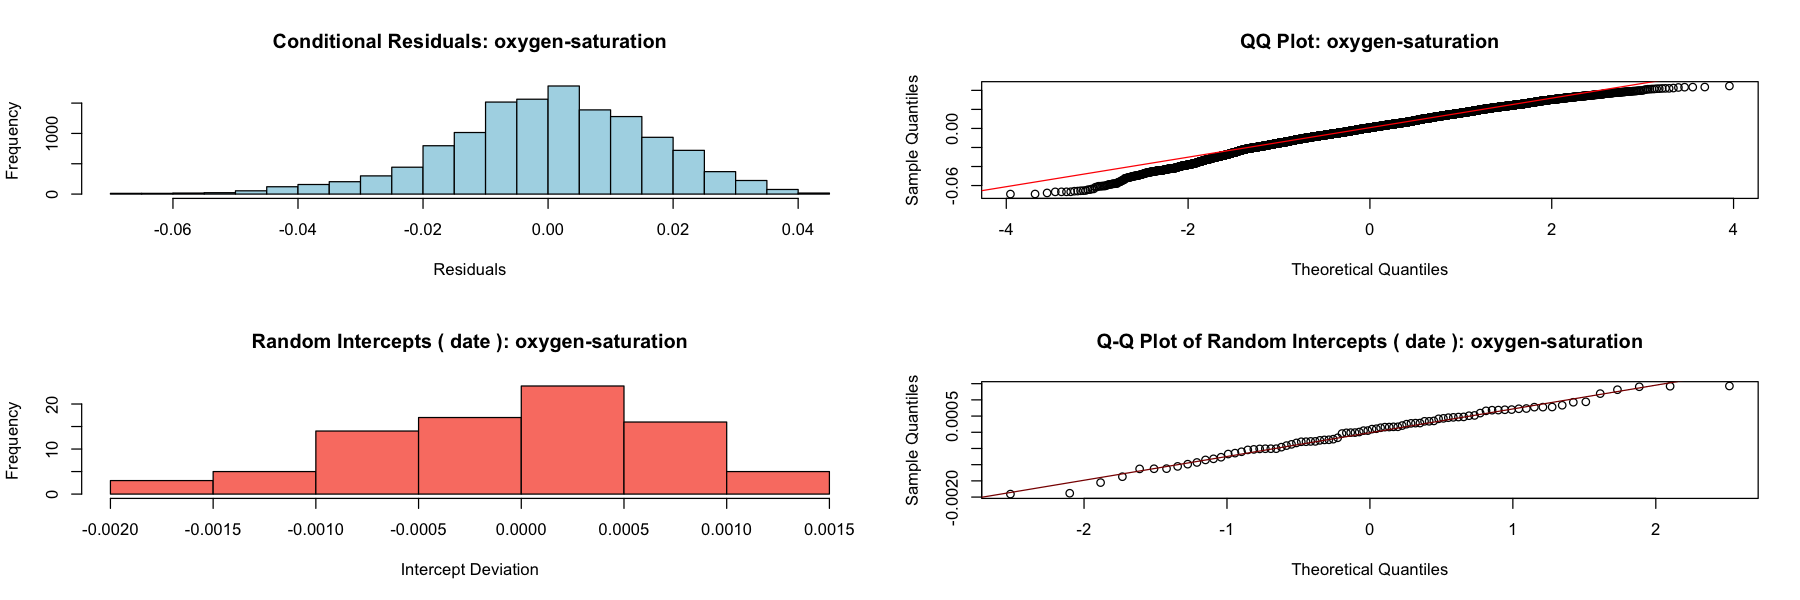

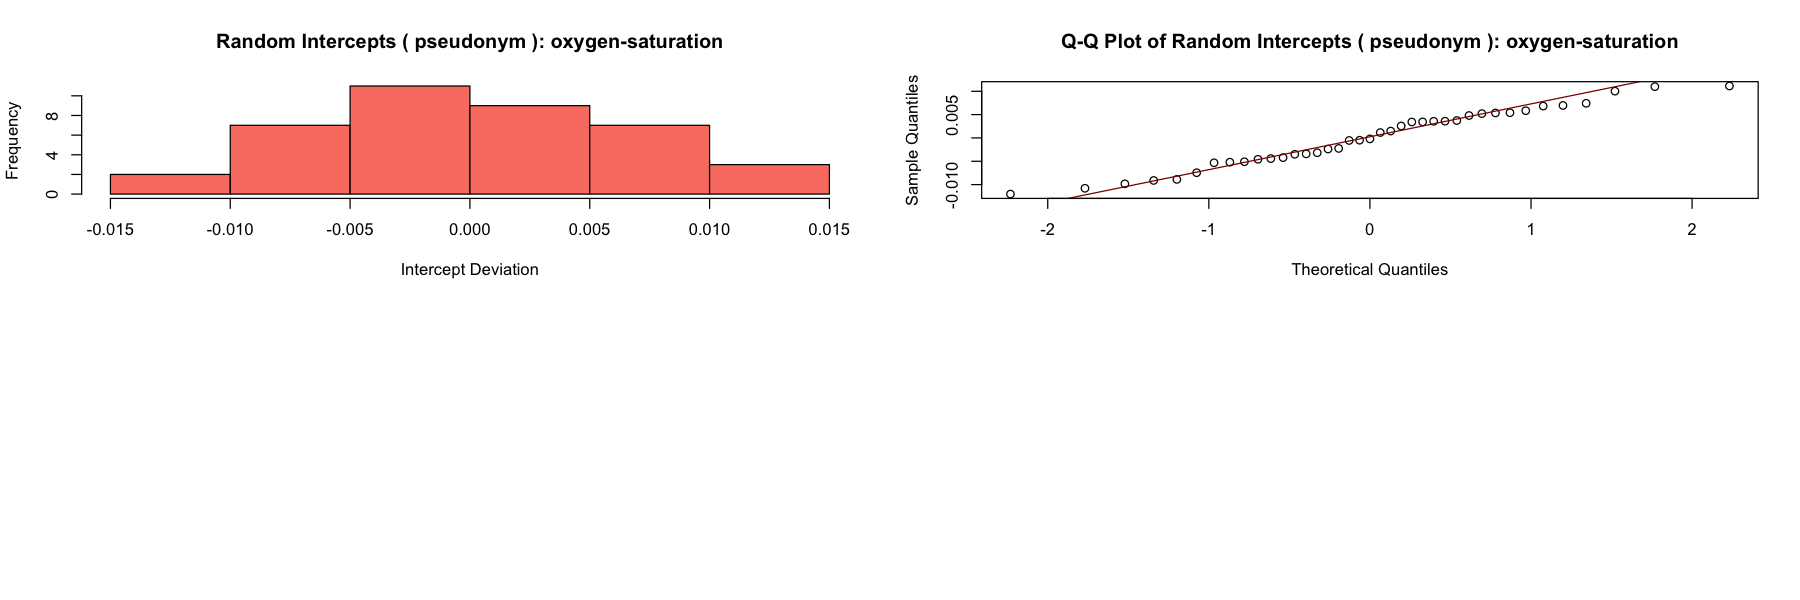

In [17]:
plot_lme_diagnostics(health_metric_pm25_lme_summaries)

### 5.2.3. Sensitivity Analysis
PM2.5 exposure (restricted to at-home periods only) <-> Health metric

In [18]:
pm25_lme_models_sensitivity <- fit_lme_models(
    main_fixed_effect = "pm25",
    optional_filter_by_location_type = "home",
    metric_dfs = HEALTH_METRIC_WITH_EXPOSURE_DFS
)
pm25_lme_summaries_sensitivity <- imap(pm25_lme_models_sensitivity, 
    ~extract_model_info(
        model = .x$model,
        main_fixed_effect_iqr = .x$main_fixed_effect_iqr,
        df_used = .x$df_used,
        metric_name = .y,
        main_fixed_effect = "pm25"
        )
    )
    
pm25_lme_summaries_sensitivity <- adjust_pvalues_bh(lme_summaries = pm25_lme_summaries_sensitivity, main_fixed_effect = "pm25")

[1] "Fitting model for metric: heart-rate"
[1] "Fitting model for metric: resting-heart-rate"


boundary (singular) fit: see help('isSingular')



[1] "Fitting model for metric: hrv"
[1] "Fitting model for metric: respiratory-rate"
[1] "Fitting model for metric: oxygen-saturation"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 141510' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 141510)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 141510' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 141510)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for heart-rate = 66.48"
[1] "Adjusted overall mean for resting-heart-rate = 63.66"


...

[1] "Adjusted overall mean for hrv = 54.86"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 35077' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 35077)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 35077' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 35077)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for respiratory-rate = 14.74"


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 10641' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 10641)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 10641' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 10641)' or larger];
but be warned that this may result in large computation time and memory use.



[1] "Adjusted overall mean for oxygen-saturation = 97.21"


[1] "Saved image"


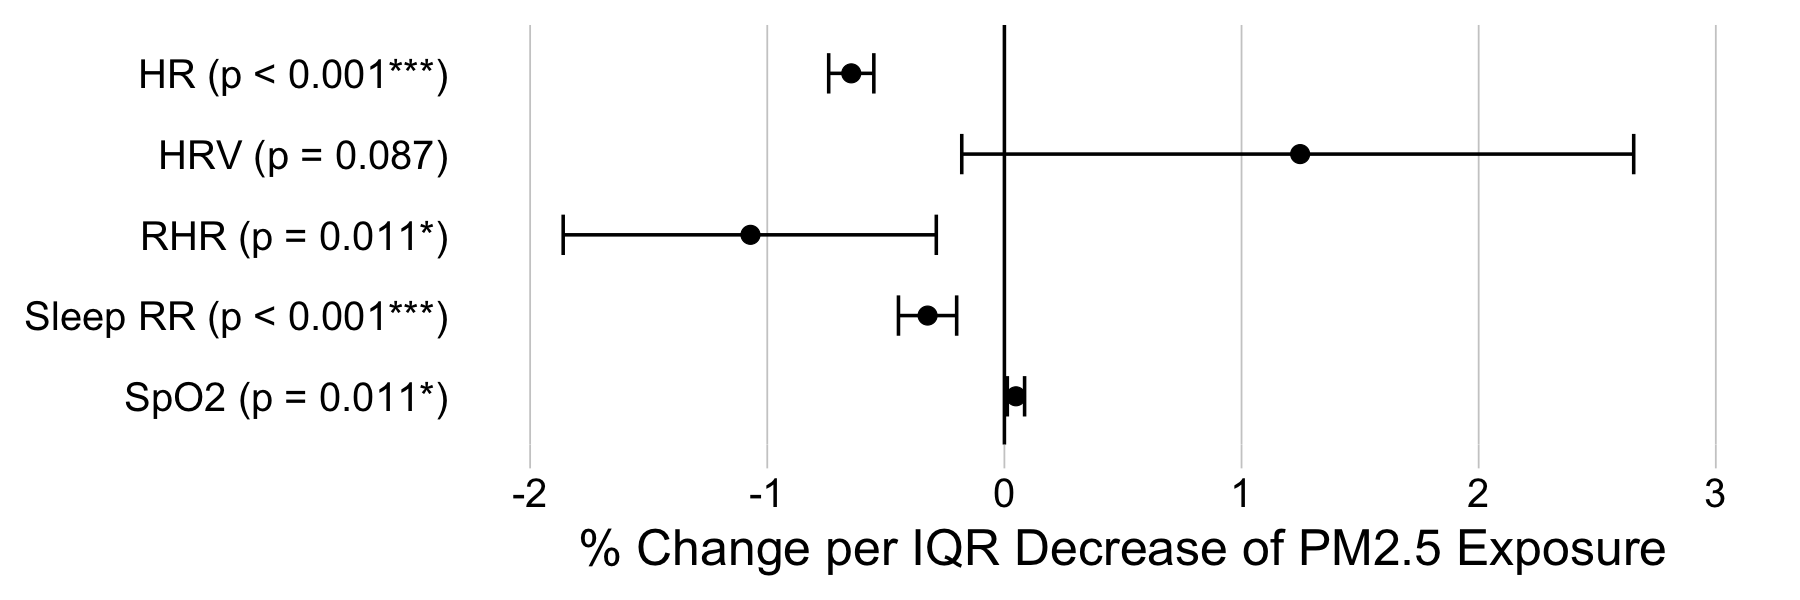

In [19]:
plot_fixed_effect_percentage(
    main_fixed_effect = "pm25",
    summaries = pm25_lme_summaries_sensitivity, 
    health_metric_names = HEALTH_METRIC_NAMES, 
    is_black_bg = FALSE,
    title = "% Change per IQR Decrease of PM2.5 Exposure",
    flip_direction = TRUE,
    optional_filter_by_location_type = "home",
    file_name = "percentage_change_health_metrics_pm25_home_only.pdf"
)

In [20]:
pm25_sensitivity_report_df <- make_reporting_pm25_df(
  lme_summaries = pm25_lme_summaries_sensitivity,
  pm25_term = "pm25",
  flip_direction = TRUE,
  metric_labels = HEALTH_METRIC_LABELS_LATEX
)

pm25_sensitivity_report_df

latex_tbl <- kable(
  pm25_sensitivity_report_df, "latex", booktabs = TRUE, escape = FALSE,
  align = "llcccc",
  col.names = c(
  "Metric", "PM2.5 IQR", "Mean Percentage Change [95\\% CI]", "P-Value\\tnote{a}"),
  label = "health_metrics_vs_pm25"
                   ) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))

latex_tbl

metric,main_fixed_effect_iqr,pct_change_iqr,p_value
<chr>,<dbl>,<chr>,<chr>
HR (beats/min),5.4,"$-0.65\%$ $[-0.74, -0.55]$",\textbf{<0.001$^{***}$}
HRV (ms),5.5,"$+1.25\%$ $[-0.18, +2.65]$",0.087
RHR (beats/min),7.4,"$-1.07\%$ $[-1.86, -0.29]$",\textbf{0.011$^*$}
Sleep RR (breaths/min),5.3,"$-0.32\%$ $[-0.45, -0.20]$",\textbf{<0.001$^{***}$}
SpO$_2$ (\%),5.4,"$+0.05\%$ $[+0.01, +0.09]$",\textbf{0.011$^*$}


\begin{table}[!h]
\centering
\begin{tabular}{llcc}
\toprule
Metric & PM2.5 IQR & Mean Percentage Change [95\% CI] & P-Value\tnote{a}\\
\midrule
HR (beats/min) & 5.4 & $-0.65\%$ $[-0.74, -0.55]$ & \textbf{<0.001$^{***}$}\\
HRV (ms) & 5.5 & $+1.25\%$ $[-0.18, +2.65]$ & 0.087\\
RHR (beats/min) & 7.4 & $-1.07\%$ $[-1.86, -0.29]$ & \textbf{0.011$^*$}\\
Sleep RR (breaths/min) & 5.3 & $-0.32\%$ $[-0.45, -0.20]$ & \textbf{<0.001$^{***}$}\\
SpO$_2$ (\%) & 5.4 & $+0.05\%$ $[+0.01, +0.09]$ & \textbf{0.011$^*$}\\
\bottomrule
\end{tabular}
\end{table}

# 5.3. LME for sleep stages durations

### 5.3.1. Treatment <-> Sleep stages durations

In [21]:
sleep_stage_treatment_lme_models <- fit_lme_models(
    main_fixed_effect = "treatment",
    optional_filter_by_location_type = "home",
    metric_dfs = SLEEP_STAGE_WITH_EXPOSURE_DFS
)

sleep_stage_treatment_lme_summaries <- imap(
  sleep_stage_treatment_lme_models,
  ~ extract_model_info(
      model = .x$model,
      main_fixed_effect_iqr = .x$main_fixed_effect_iqr,
      df_used = .x$df_used,
      metric_name = .y,
      main_fixed_effect = "treatment"
    )
)

sleep_stage_treatment_lme_summaries <- adjust_pvalues_bh(lme_summaries = sleep_stage_treatment_lme_summaries, main_fixed_effect = "treatmenttreatment2")

[1] "Fitting model for metric: awake"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Fitting model for metric: asleep_core"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Fitting model for metric: asleep_deep"


...

[1] "Fitting model for metric: asleep_rem"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Fitting model for metric: alseep_all"


Warning message in quantile(as.numeric(x), c(0.25, 0.75), na.rm = na.rm, names = FALSE, :
“NAs introduced by coercion”


[1] "Adjusted overall mean for awake = 0.16"
[1] "Adjusted overall mean for asleep_core = 3.94"
[1] "Adjusted overall mean for asleep_deep = 0.86"
[1] "Adjusted overall mean for asleep_rem = 1.36"
[1] "Adjusted overall mean for alseep_all = 6.65"


In [22]:
view_lme_summary_details(lme_summaries = sleep_stage_treatment_lme_summaries)

log(value) ~ treatment + bmi + biological_sex + ns(temperature, 
    df = 3) + ns(humidity, df = 3) + ns(co2, df = 3) + dow + 
    heart_rate_motion_context + (1 | pseudonym + date)
<environment: 0x139d8bc80>

metric,REMLcrit,residual_stddev,nobs
<chr>,<dbl>,<dbl>,<int>
awake,2038.31,0.9144079,730


effect,term,estimate,2.5 %,97.5 %,std.error,statistic,df,p.value,percent_change,percent_change_low,percent_change_high,percent_change_iqr,percent_change_iqr_low,percent_change_iqr_high,adjusted_p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),-3.26992577,-4.659660601,-1.88019094,0.70906141,-4.6116256,395.29937,5.403504e-06,NA,NA,NA,NA,NA,NA,NA
fixed,treatmenttreatment2,0.05844010,-0.078943847,0.19582405,0.07009514,0.8337255,666.40096,4.047344e-01,6.018148,-7.5908187,21.631288,NA,NA,NA,0.421319
fixed,bmi,0.13681879,-0.071433469,0.34507104,0.10625310,1.2876686,37.86045,2.056770e-01,14.662035,-6.8941780,41.209024,NA,NA,NA,NA
fixed,biological_sexMale,-0.26994865,-0.682015285,0.14211799,0.21024194,-1.2839905,35.58122,2.074436e-01,-23.658130,-49.4402957,15.271265,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)1",-0.52786748,-1.429774502,0.37403954,0.46016510,-1.1471263,517.76481,2.518592e-01,-41.013848,-76.0637108,45.359463,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)2",0.88428524,-1.089370365,2.85794085,1.00698565,0.8781508,311.30842,3.805391e-01,142.125317,-66.3571746,1642.560807,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)3",1.67745687,-0.232752876,3.58766662,0.97461472,1.7211487,707.49860,8.566101e-02,435.192802,-20.7650642,3514.962667,NA,NA,NA,NA
fixed,"ns(humidity, df = 3)1",0.05881835,-0.601736272,0.71937296,0.33702386,0.1745228,353.09324,8.615546e-01,6.058256,-45.2140423,105.314541,NA,NA,NA,NA
fixed,"ns(humidity, df = 3)2",1.89765025,-0.215954861,4.01125536,1.07838977,1.7597072,592.60253,7.897339e-02,567.020271,-19.4228327,5421.614327,NA,NA,NA,NA


effect,group,term,variance,std.dev,2.5 %,97.5 %
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ran_pars,date,sd__(Intercept),0.01734517,0.1317010,NA,NA
ran_pars,pseudonym,sd__(Intercept),0.30790244,0.5548896,NA,NA
ran_pars,Residual,sd__Observation,0.83614183,0.9144079,NA,NA


,treatment,response,SE,df,lower.CL,upper.CL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,treatment1,0.1588074,0.01908045,56.86086,0.1248467,0.2020061
2,treatment2,0.1683646,0.02012262,56.87022,0.1325274,0.2138928


...

metric,REMLcrit,residual_stddev,nobs
<chr>,<dbl>,<dbl>,<int>
alseep_all,281.906,0.2665942,796


effect,term,estimate,2.5 %,97.5 %,std.error,statistic,df,p.value,percent_change,percent_change_low,percent_change_high,percent_change_iqr,percent_change_iqr_low,percent_change_iqr_high,adjusted_p.value
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
fixed,(Intercept),1.66227910,1.2878973161,2.036660877,0.19101462,8.7023657,413.43748,7.806983e-17,NA,NA,NA,NA,NA,NA,NA
fixed,treatmenttreatment2,-0.03267205,-0.0708778098,0.005533712,0.01949309,-1.6760833,717.21091,9.415769e-02,-3.214408,-6.8424285,0.5549051,NA,NA,NA,0.2188938
fixed,bmi,-0.02490538,-0.0666951134,0.016884354,0.02132168,-1.1680775,34.22047,2.508494e-01,-2.459780,-6.4519627,1.7027701,NA,NA,NA,NA
fixed,biological_sexMale,-0.02514420,-0.1066320211,0.056343629,0.04157618,-0.6047740,33.16000,5.494455e-01,-2.483071,-10.1143628,5.7961168,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)1",0.04353693,-0.1544329729,0.241506838,0.10100691,0.4310293,298.97715,6.667577e-01,4.449857,-14.3099074,27.3166161,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)2",-0.79914362,-1.2894653962,-0.308821834,0.25016877,-3.1944180,273.80752,1.564951e-03,-55.028607,-72.4582017,-26.5688412,NA,NA,NA,NA
fixed,"ns(temperature, df = 3)3",-1.29000395,-1.7439392161,-0.836068678,0.23160388,-5.5698718,641.95890,3.751863e-08,-72.473030,-82.5169652,-56.6588943,NA,NA,NA,NA
fixed,"ns(humidity, df = 3)1",0.04157235,-0.1342846559,0.217429352,0.08972461,0.4633327,327.90263,6.434333e-01,4.244858,-12.5658857,24.2877620,NA,NA,NA,NA
fixed,"ns(humidity, df = 3)2",0.30971554,-0.2749811034,0.894412182,0.29832010,1.0381987,586.32591,2.996055e-01,36.303733,-24.0413523,144.5897623,NA,NA,NA,NA


effect,group,term,variance,std.dev,2.5 %,97.5 %
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ran_pars,date,sd__(Intercept),0.001367028,0.03697334,NA,NA
ran_pars,pseudonym,sd__(Intercept),0.010269518,0.10133863,NA,NA
ran_pars,Residual,sd__Observation,0.071072449,0.26659417,NA,NA


,treatment,response,SE,df,lower.CL,upper.CL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,treatment1,6.762378,0.1758223,74.29424,6.420986,7.121921
2,treatment2,6.545007,0.1720004,77.65228,6.211361,6.896575


[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"
[1] "main_fixed_effect_iqr: NA"


[1] "Saved image"


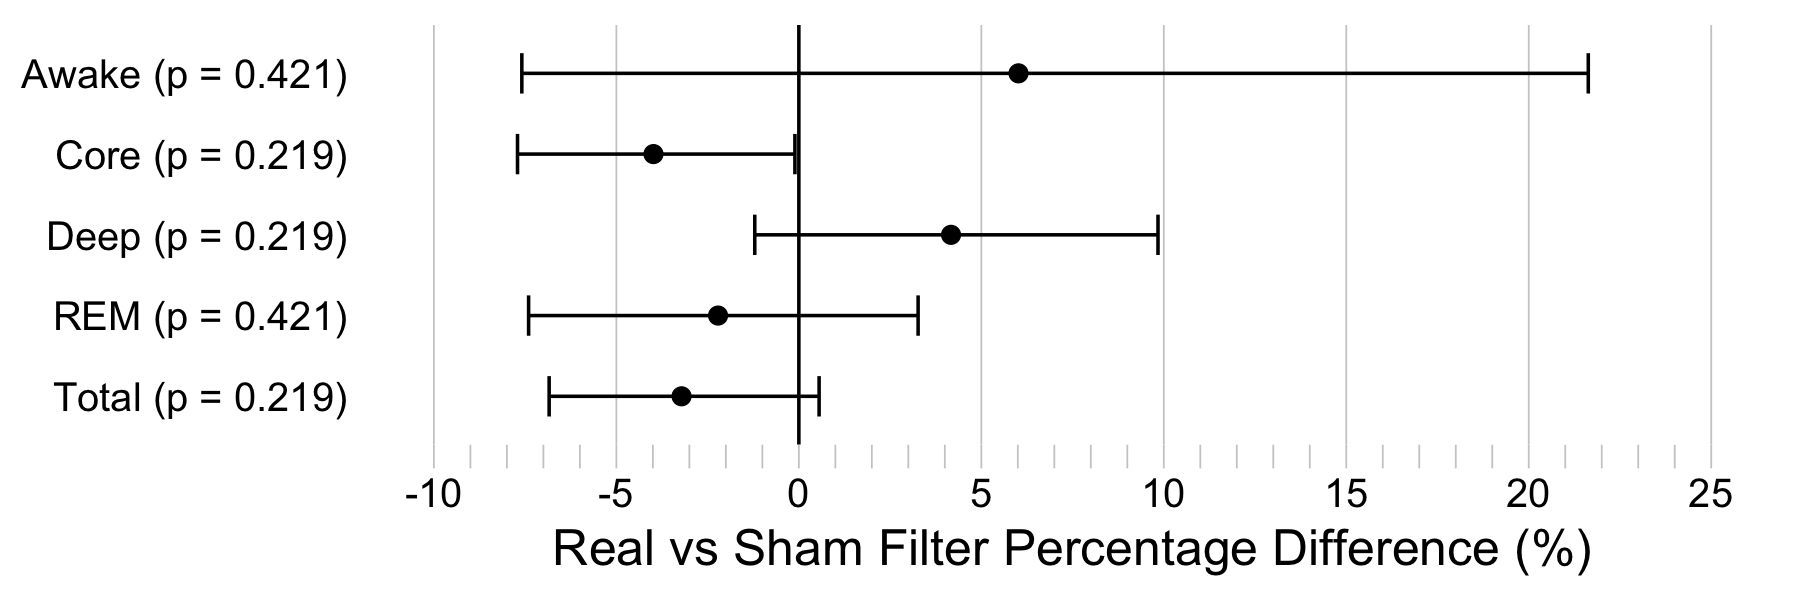

In [23]:
plot_fixed_effect_percentage(
    main_fixed_effect =  "treatmenttreatment2",
    summaries = sleep_stage_treatment_lme_summaries, 
    health_metric_names = SLEEP_STAGE_NAMES, 
    is_black_bg = FALSE,
    title = "Real vs Sham Filter Percentage Difference (%)",
    file_name = "percentage_change_sleep_stages_treatment.pdf"
)

In [24]:
sleep_stage_treatment_report_df <- make_reporting_treatment_df(
  lme_summaries = sleep_stage_treatment_lme_summaries,
  trt1 = "treatment1",
  trt2 = "treatment2",
  trt2_term = "treatmenttreatment2",
  metric_labels = SLEEP_STAGE_LABELS_LATEX
)

sleep_stage_treatment_report_df

latex_tbl <- kable(
  sleep_stage_treatment_report_df, "latex", booktabs = TRUE, escape = FALSE,
  align = "llcccc",
  col.names = c(
  "Sleep Stage",  TREATMENT_LABELS[TREATMENT_1_NAME], TREATMENT_LABELS[TREATMENT_2_NAME], "Percentage Changes (Real vs. Sham)", "P-Value\\tnote{a}"),
  label = "sleep_stage_vs_treatment"
                   ) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))

latex_tbl

metric,emmean1_pm_se,emmean2_pm_se,pct_change_iqr,p_value
<chr>,<chr>,<chr>,<chr>,<chr>
Awake (h),$0.16~\pm~0.02$,$0.17~\pm~0.02$,"$+6.02\%$ $[-7.59, +21.63]$",0.421
Core (h),$4.02~\pm~0.14$,$3.86~\pm~0.13$,"$-3.98\%$ $[-7.71, -0.11]$",0.219
Deep (h),$0.84~\pm~0.04$,$0.88~\pm~0.04$,"$+4.17\%$ $[-1.21, +9.84]$",0.219
REM (h),$1.38~\pm~0.07$,$1.34~\pm~0.06$,"$-2.21\%$ $[-7.41, +3.27]$",0.421
Total (h),$6.76~\pm~0.18$,$6.55~\pm~0.17$,"$-3.21\%$ $[-6.84, +0.55]$",0.219


\begin{table}[!h]
\centering
\begin{tabular}{llccc}
\toprule
Sleep Stage & Sham Filter & Real Filter & Percentage Changes (Real vs. Sham) & P-Value\tnote{a}\\
\midrule
Awake (h) & $0.16~\pm~0.02$ & $0.17~\pm~0.02$ & $+6.02\%$ $[-7.59, +21.63]$ & 0.421\\
Core (h) & $4.02~\pm~0.14$ & $3.86~\pm~0.13$ & $-3.98\%$ $[-7.71, -0.11]$ & 0.219\\
Deep (h) & $0.84~\pm~0.04$ & $0.88~\pm~0.04$ & $+4.17\%$ $[-1.21, +9.84]$ & 0.219\\
REM (h) & $1.38~\pm~0.07$ & $1.34~\pm~0.06$ & $-2.21\%$ $[-7.41, +3.27]$ & 0.421\\
Total (h) & $6.76~\pm~0.18$ & $6.55~\pm~0.17$ & $-3.21\%$ $[-6.84, +0.55]$ & 0.219\\
\bottomrule
\end{tabular}
\end{table}

### 5.3.2. PM2.5 exposure <-> Sleep stages durations

In [25]:
sleep_stage_pm25_lme_models <- fit_lme_models(
    main_fixed_effect = "pm25",
    metric_dfs = SLEEP_STAGE_WITH_EXPOSURE_DFS
)
sleep_stage_pm25_lme_summaries <- imap(sleep_stage_pm25_lme_models, 
    ~extract_model_info(
        model = .x$model,
        main_fixed_effect_iqr = .x$main_fixed_effect_iqr,
        df_used = .x$df_used,
        metric_name = .y,
        main_fixed_effect = "pm25"
        )
    )
    
sleep_stage_pm25_lme_summaries <- adjust_pvalues_bh(lme_summaries = sleep_stage_pm25_lme_summaries, main_fixed_effect = "pm25")

[1] "Fitting model for metric: awake"
[1] "Fitting model for metric: asleep_core"
[1] "Fitting model for metric: asleep_deep"


boundary (singular) fit: see help('isSingular')



[1] "Fitting model for metric: asleep_rem"
[1] "Fitting model for metric: alseep_all"
[1] "Adjusted overall mean for awake = 0.16"
[1] "Adjusted overall mean for asleep_core = 3.94"
[1] "Adjusted overall mean for asleep_deep = 0.86"
[1] "Adjusted overall mean for asleep_rem = 1.36"
[1] "Adjusted overall mean for alseep_all = 6.66"


[1] "Saved image"


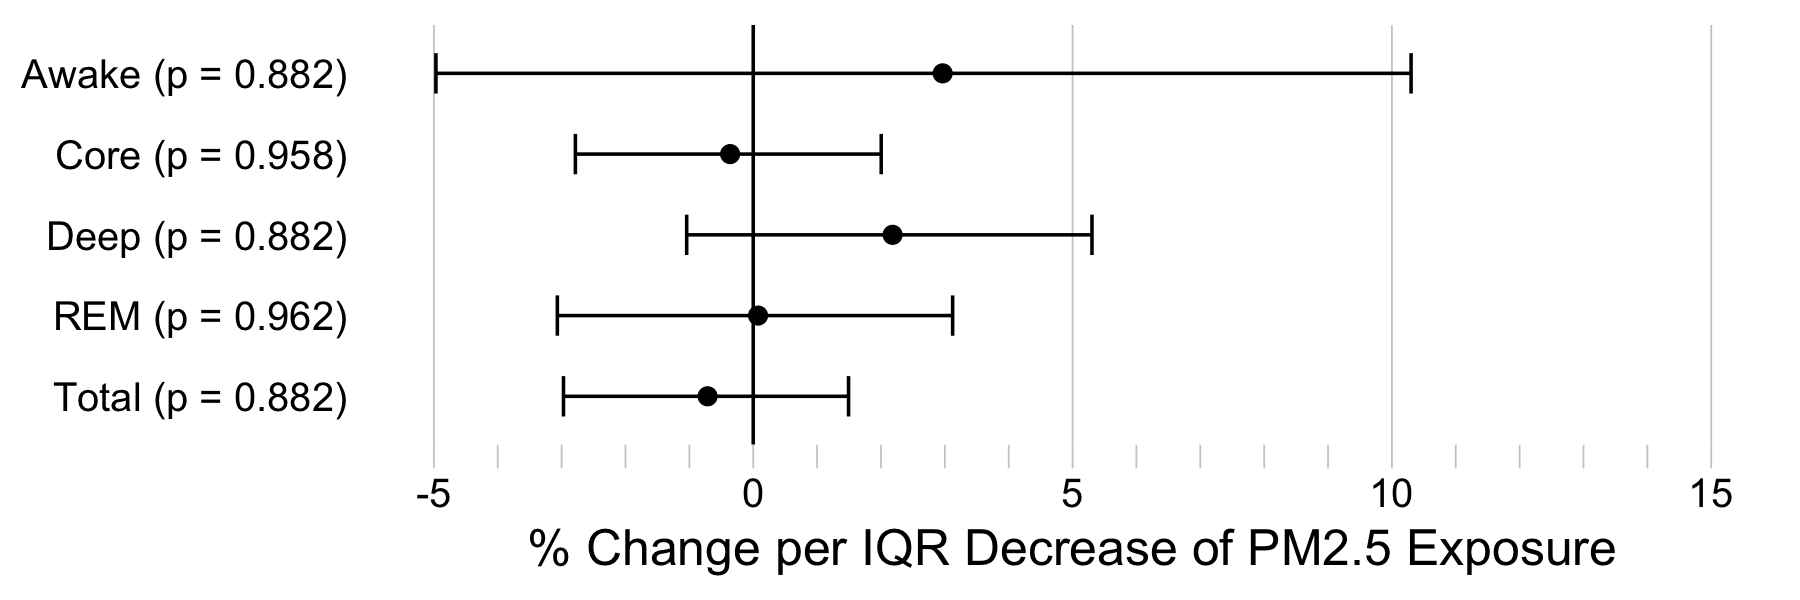

In [26]:
plot_fixed_effect_percentage(
    main_fixed_effect = "pm25",
    summaries = sleep_stage_pm25_lme_summaries, 
    health_metric_names = SLEEP_STAGE_NAMES, 
    is_black_bg = FALSE,
    title = "% Change per IQR Decrease of PM2.5 Exposure",
    flip_direction = TRUE,
    file_name = "percentage_change_sleep_stages_pm25.pdf"
)

In [27]:
sleep_stage_pm25_report_df <- make_reporting_pm25_df(
  lme_summaries = sleep_stage_pm25_lme_summaries,
  pm25_term = "pm25",
  flip_direction = TRUE,
  metric_labels = SLEEP_STAGE_LABELS_LATEX
)

sleep_stage_pm25_report_df

latex_tbl <- kable(
  sleep_stage_pm25_report_df, "latex", booktabs = TRUE, escape = FALSE,
  align = "llcccc",
  col.names = c(
  "Sleep Stage", "PM2.5 IQR", "Mean Percentage Change [95\\% CI]", "P-Value\\tnote{a}"),
  label = "sleep_stage_vs_pm25"
                   ) |>
  kable_styling(latex_options = c("hold_position", "repeat_header"))

latex_tbl

metric,main_fixed_effect_iqr,pct_change_iqr,p_value
<chr>,<dbl>,<chr>,<chr>
Awake (h),5.9,"$+2.97\%$ $[-4.97, +10.30]$",0.882
Core (h),5.6,"$-0.36\%$ $[-2.78, +2.00]$",0.958
Deep (h),6.1,"$+2.18\%$ $[-1.04, +5.30]$",0.882
REM (h),5.6,"$+0.08\%$ $[-3.07, +3.12]$",0.962
Total (h),5.6,"$-0.71\%$ $[-2.97, +1.49]$",0.882


\begin{table}[!h]
\centering
\begin{tabular}{llcc}
\toprule
Sleep Stage & PM2.5 IQR & Mean Percentage Change [95\% CI] & P-Value\tnote{a}\\
\midrule
Awake (h) & 5.9 & $+2.97\%$ $[-4.97, +10.30]$ & 0.882\\
Core (h) & 5.6 & $-0.36\%$ $[-2.78, +2.00]$ & 0.958\\
Deep (h) & 6.1 & $+2.18\%$ $[-1.04, +5.30]$ & 0.882\\
REM (h) & 5.6 & $+0.08\%$ $[-3.07, +3.12]$ & 0.962\\
Total (h) & 5.6 & $-0.71\%$ $[-2.97, +1.49]$ & 0.882\\
\bottomrule
\end{tabular}
\end{table}